## Import Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Load HMF v3_iter3 data (with mass cut 1e11)
from galform_analysis.config import get_base_dir
from galform_analysis.analysis import (
    completed_galaxies,
    avg_correlation_given_redshift_and_subvolumes,
)
from galform_analysis.analysis.correlation.correlation import avg_correlation_given_redshift_and_subvolumes


project_root = Path.cwd()
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

base_dir = Path(get_base_dir())
workspace_root = Path('/cosma/home/durham/dc-hick2/galform_analysis')

## HMF CONVERGENCE PLOTS: Compare n_ivols to 1024 referenc

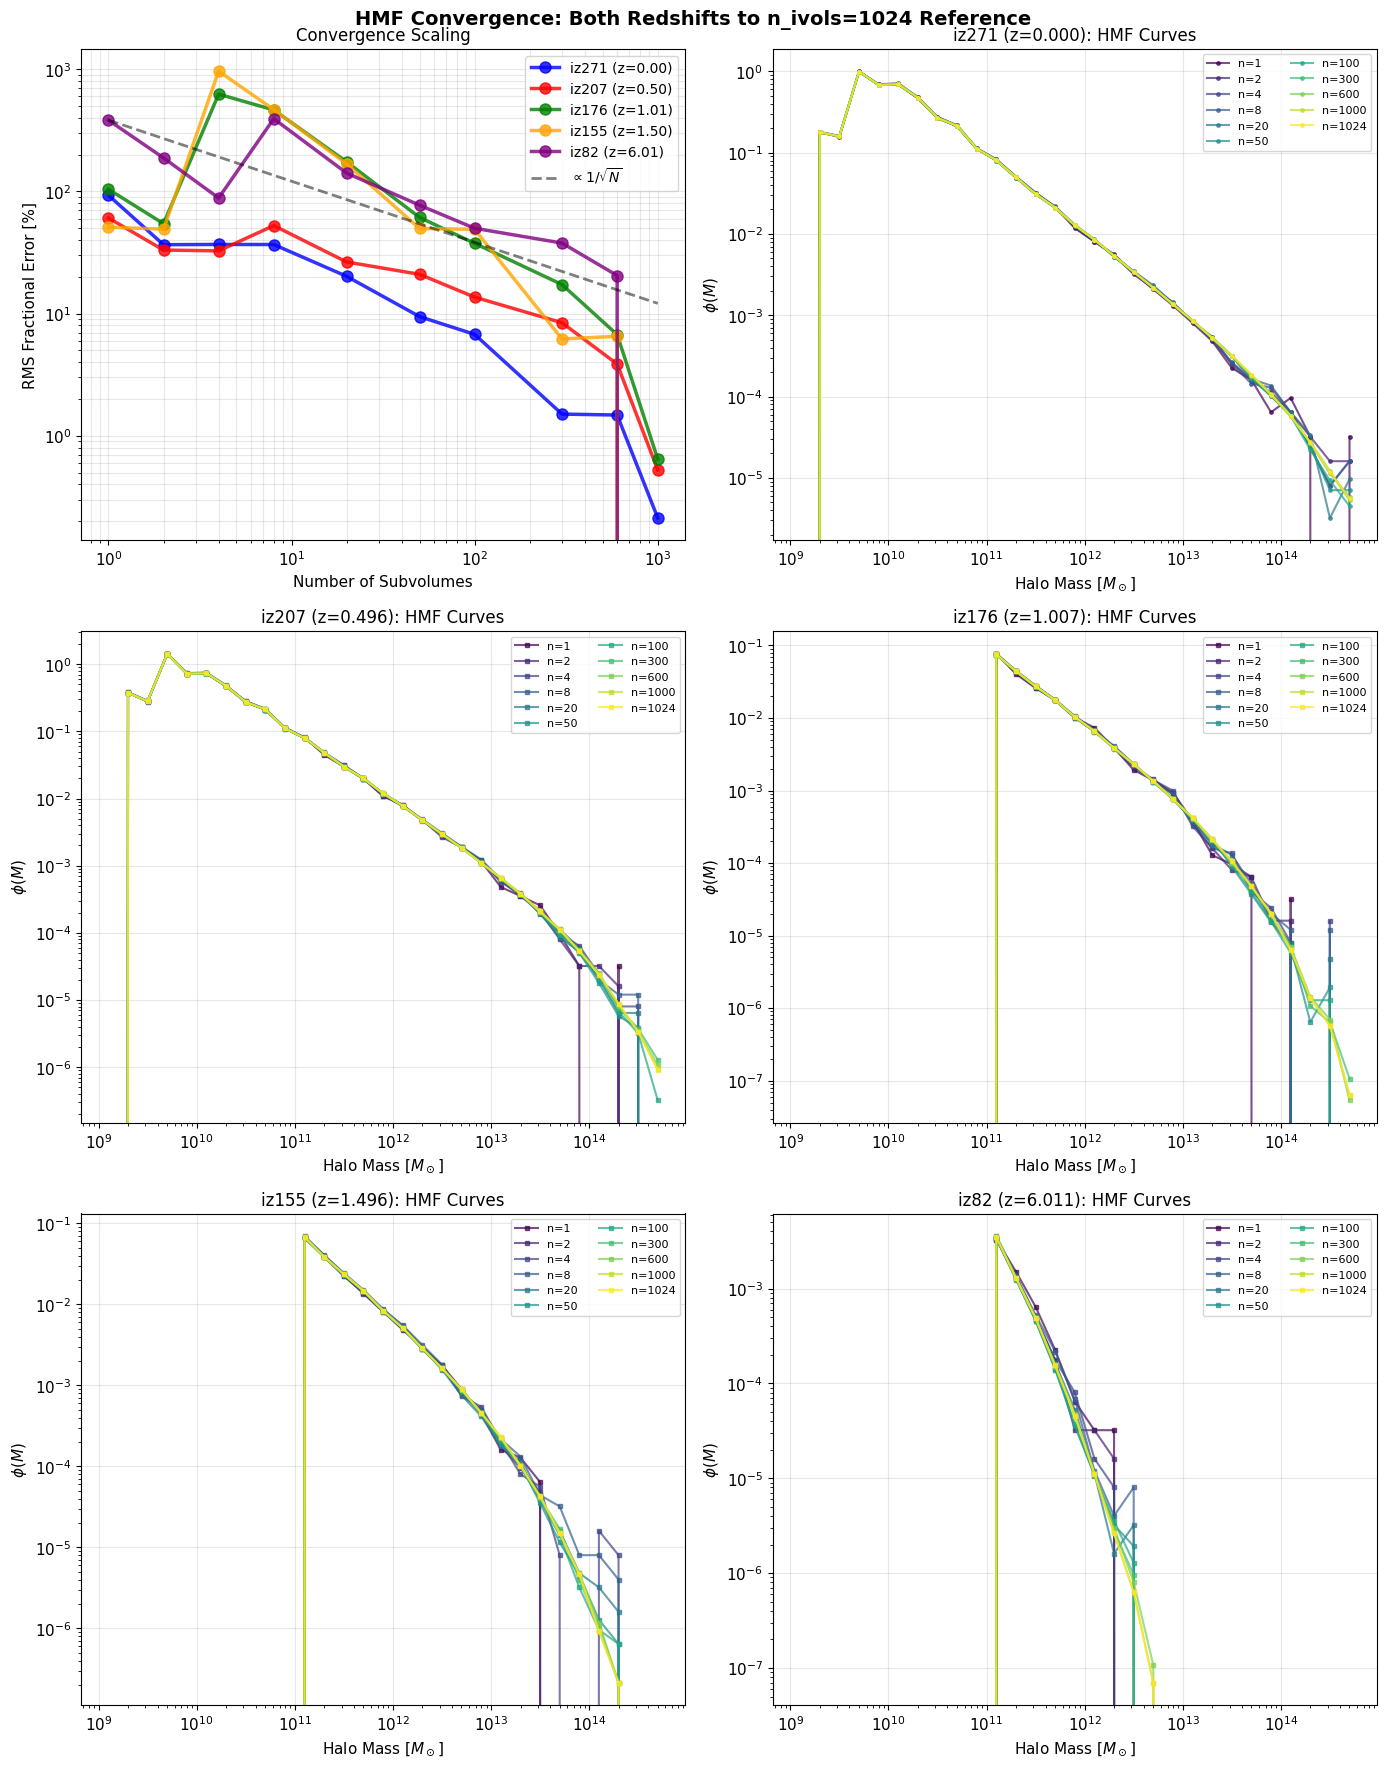

In [ ]:

hmf_iz271 = pd.read_csv(workspace_root / 'convergence_results' / 'hmf_convergence_iz271.csv')
hmf_iz207 = pd.read_csv(workspace_root / 'convergence_results' / 'hmf_convergence_iz207.csv')
hmf_iz176 = pd.read_csv(workspace_root / 'convergence_results' / 'hmf_convergence_iz176.csv')
hmf_iz155 = pd.read_csv(workspace_root / 'convergence_results' / 'hmf_convergence_iz155.csv')
hmf_iz82 = pd.read_csv(workspace_root / 'convergence_results' / 'hmf_convergence_iz82.csv')

# Create convergence plots with both redshifts overlaid
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('HMF Convergence: Both Redshifts to n_ivols=1024 Reference', fontsize=14, fontweight='bold')

redshift_data = [(hmf_iz271, 'iz271', 'blue'), (hmf_iz207, 'iz207', 'red'), (hmf_iz176, 'iz176', 'green'), (hmf_iz155, 'iz155', 'orange'), (hmf_iz82, 'iz82', 'purple')]

# Subplot 1: Convergence metric (all redshifts overlaid)
ax = axes[0, 0]
for hmf_data, iz_label, color in redshift_data:
    hmf_ref = hmf_data[hmf_data['n_ivols'] == 1024].sort_values('log_Mhalo')
    n_ivols_list = sorted(hmf_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
        ref_phi = hmf_ref['phi'].values
        hmf_phi = hmf_subset['phi'].values
        valid = (ref_phi > 0) & np.isfinite(ref_phi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((hmf_phi[valid] - ref_phi[valid]) / ref_phi[valid])**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    ax.loglog(conv_df['n_ivols'], conv_df['rms_diff'], marker='o', markersize=8, 
              color=color, linewidth=2.5, label=f'{iz_label} (z={hmf_data["z"].iloc[0]:.2f})', alpha=0.8)

n_ref_plot = conv_df['n_ivols'].values
rms_ref_plot = conv_df['rms_diff'].iloc[0]
ax.loglog(n_ref_plot, rms_ref_plot * np.sqrt(n_ref_plot[0] / n_ref_plot), 'k--', linewidth=2, 
          label=r'$\propto 1/\sqrt{N}$', alpha=0.5)
ax.set_xlabel('Number of Subvolumes', fontsize=11)
ax.set_ylabel('RMS Fractional Error [%]', fontsize=11)
ax.set_title('Convergence Scaling', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 2: HMF curves (iz271)
ax = axes[0, 1]
hmf_data = hmf_iz271
n_ivols_list = sorted(hmf_data['n_ivols'].unique())
colors_n = plt.cm.viridis(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
    ax.loglog(10**hmf_subset['log_Mhalo'], hmf_subset['phi'], marker='o', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Halo Mass [$M_\odot$]', fontsize=11)
ax.set_ylabel('$\phi(M)$', fontsize=11)
ax.set_title(f'iz271 (z={hmf_iz271["z"].iloc[0]:.3f}): HMF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# Subplot 3: HMF curves (iz207)
ax = axes[1, 0]
hmf_data = hmf_iz207
n_ivols_list = sorted(hmf_data['n_ivols'].unique())
colors_n = plt.cm.viridis(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
    ax.loglog(10**hmf_subset['log_Mhalo'], hmf_subset['phi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Halo Mass [$M_\odot$]', fontsize=11)
ax.set_ylabel('$\phi(M)$', fontsize=11)
ax.set_title(f'iz207 (z={hmf_iz207["z"].iloc[0]:.3f}): HMF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# Subplot 4: HMF curves (iz176)
ax = axes[1, 1]
hmf_data = hmf_iz176
n_ivols_list = sorted(hmf_data['n_ivols'].unique())
colors_n = plt.cm.viridis(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
    ax.loglog(10**hmf_subset['log_Mhalo'], hmf_subset['phi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Halo Mass [$M_\odot$]', fontsize=11)
ax.set_ylabel('$\phi(M)$', fontsize=11)
ax.set_title(f'iz176 (z={hmf_iz176["z"].iloc[0]:.3f}): HMF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# Subplot 5: HMF curves (iz155)
ax = axes[2, 0]
hmf_data = hmf_iz155
n_ivols_list = sorted(hmf_data['n_ivols'].unique())
colors_n = plt.cm.viridis(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
    ax.loglog(10**hmf_subset['log_Mhalo'], hmf_subset['phi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Halo Mass [$M_\odot$]', fontsize=11)
ax.set_ylabel('$\phi(M)$', fontsize=11)
ax.set_title(f'iz155 (z={hmf_iz155["z"].iloc[0]:.3f}): HMF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

#Subplot 6: HMF curves (iz82)
ax = axes[2, 1]
hmf_data = hmf_iz82
n_ivols_list = sorted(hmf_data['n_ivols'].unique())
colors_n = plt.cm.viridis(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
    ax.loglog(10**hmf_subset['log_Mhalo'], hmf_subset['phi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Halo Mass [$M_\odot$]', fontsize=11)
ax.set_ylabel('$\phi(M)$', fontsize=11)
ax.set_title(f'iz82 (z={hmf_iz82["z"].iloc[0]:.3f}): HMF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# # Subplot 7: Statistics table
# ax = axes[3, 0]
# ax.axis('off')
# stats_text = "RMS Error Statistics:\n\n"
# for hmf_data, iz_label, _ in redshift_data:
#     hmf_ref = hmf_data[hmf_data['n_ivols'] == 1024].sort_values('log_Mhalo')
#     n_ivols_list = sorted(hmf_data['n_ivols'].unique())
#     convergence_metric = []
#     for n_ivol in n_ivols_list[:-1]:
#         hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
#         ref_phi = hmf_ref['phi'].values
#         hmf_phi = hmf_subset['phi'].values
#         valid = (ref_phi > 0) & np.isfinite(ref_phi)
#         if valid.sum() > 0:
#             rms_diff = np.sqrt(np.mean(((hmf_phi[valid] - ref_phi[valid]) / ref_phi[valid])**2)) * 100
#         else:
#             rms_diff = np.nan
#         convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
#     conv_df = pd.DataFrame(convergence_metric).dropna()
#     stats_text += f"{iz_label} (z={hmf_data['z'].iloc[0]:.3f}):\n"
#     for idx, row in conv_df.iterrows():
#         stats_text += f"  n={int(row['n_ivols']):4d}: {row['rms_diff']:6.2f}%\n"
#     stats_text += "\n"
# ax.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
#         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 2PCF CONVERGENCE PLOTS: Compare n_ivols to 1024 referenc

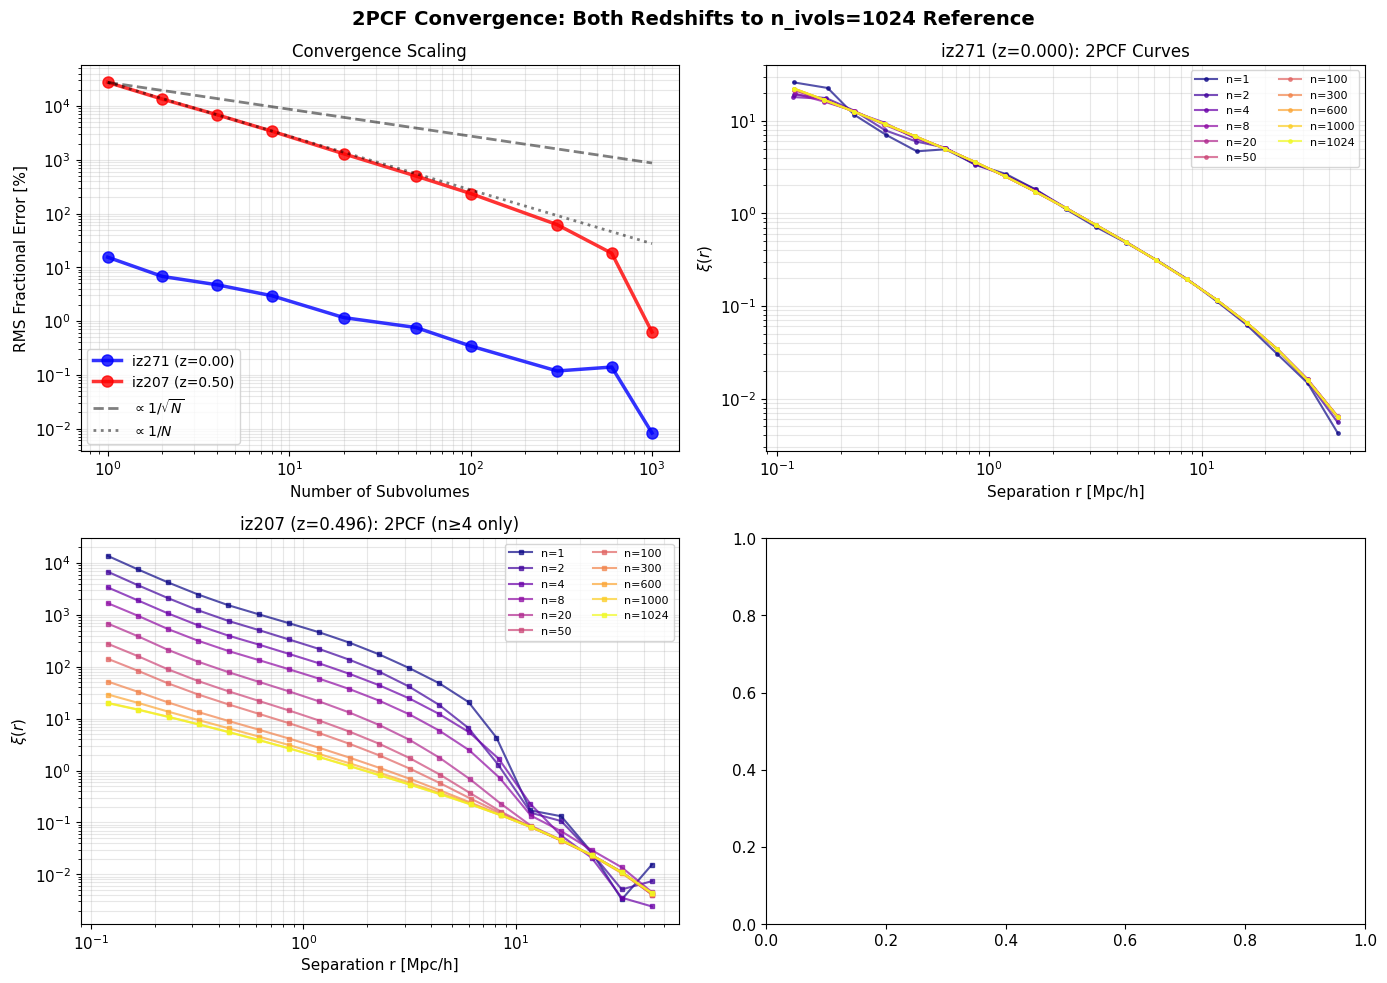

In [16]:
corr_iz271 = pd.read_csv(workspace_root / 'convergence_results' / 'corr_convergence_iz271.csv')
corr_iz207 = pd.read_csv(workspace_root / 'convergence_results' / 'corr_convergence_iz207.csv')
# corr_iz176 = pd.read_csv(workspace_root / 'convergence_results' / 'corr_convergence_iz176.csv')
# corr_iz155 = pd.read_csv(workspace_root / 'convergence_results' / 'corr_convergence_iz155.csv')
# corr_iz82 = pd.read_csv(workspace_root / 'convergence_results' / 'corr_convergence_iz82.csv')


# Create convergence plots with both redshifts overlaid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2PCF Convergence: Both Redshifts to n_ivols=1024 Reference', fontsize=14, fontweight='bold')

redshift_data_corr = [(corr_iz271, 'iz271', 'blue'), (corr_iz207, 'iz207', 'red')]#, (corr_iz176, 'iz176', 'green'), (corr_iz155, 'iz155', 'orange'), (corr_iz82, 'iz82', 'purple')]

# Subplot 1: Convergence metric (both redshifts overlaid)
ax = axes[0, 0]
for corr_data, iz_label, color in redshift_data_corr:
    corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
    n_ivols_list = sorted(corr_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
        ref_xi = corr_ref['xi'].values
        corr_xi = corr_subset['xi'].values
        valid = (ref_xi != 0) & np.isfinite(ref_xi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    ax.loglog(conv_df['n_ivols'], conv_df['rms_diff'], marker='o', markersize=8, 
              color=color, linewidth=2.5, label=f'{iz_label} (z={corr_data["z"].iloc[0]:.2f})', alpha=0.8)

n_ref_plot = conv_df['n_ivols'].values
rms_ref_plot = conv_df['rms_diff'].iloc[0]
ax.loglog(n_ref_plot, rms_ref_plot * np.sqrt(n_ref_plot[0] / n_ref_plot), 'k--', linewidth=2, 
          label=r'$\propto 1/\sqrt{N}$', alpha=0.5)
ax.loglog(n_ref_plot, rms_ref_plot * n_ref_plot[0] / n_ref_plot, 'k:', linewidth=2, 
          label=r'$\propto 1/N$', alpha=0.5)
ax.set_xlabel('Number of Subvolumes', fontsize=11)
ax.set_ylabel('RMS Fractional Error [%]', fontsize=11)
ax.set_title('Convergence Scaling', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 2: 2PCF curves (iz271)
ax = axes[0, 1]
corr_data = corr_iz271
n_ivols_list = sorted(corr_data['n_ivols'].unique())
colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='o', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz271 (z={corr_iz271["z"].iloc[0]:.3f}): 2PCF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 3: 2PCF curves (iz207) -
ax = axes[1, 0]
corr_data = corr_iz207
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz207 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz207 (z={corr_iz207["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


# #Subplot 4: 2PCF curves (iz176) 
# ax = axes[1, 1]
# corr_data = corr_iz176
# n_ivols_list = sorted(corr_data['n_ivols'].unique())

# # maybe out n=1,2 for iz176 due 
# n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

# colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
# color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
# for n_ivol in n_ivols_filtered:
#     corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
#     valid_idx = corr_subset['xi'] > 0
#     ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
#               label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
# ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
# ax.set_ylabel('$\\xi(r)$', fontsize=11)
# ax.set_title(f'iz176 (z={corr_iz176["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
# ax.legend(fontsize=8, ncol=2, loc='best')
# ax.grid(True, alpha=0.3, which='both')
# # ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
# #         transform=ax.transAxes, fontsize=9, va='top', 
# #         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


# #Subplot 5: 2PCF curves (iz155) 
# ax = axes[2, 0]
# corr_data = corr_iz155
# n_ivols_list = sorted(corr_data['n_ivols'].unique())

# # maybe out n=1,2 for iz155 due 
# n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

# colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
# color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
# for n_ivol in n_ivols_filtered:
#     corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
#     valid_idx = corr_subset['xi'] > 0
#     ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
#               label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
# ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
# ax.set_ylabel('$\\xi(r)$', fontsize=11)
# ax.set_title(f'iz155 (z={corr_iz155["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
# ax.legend(fontsize=8, ncol=2, loc='best')
# ax.grid(True, alpha=0.3, which='both')
# # ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
# #         transform=ax.transAxes, fontsize=9, va='top', 
# #         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# #Subplot 6: 2PCF curves (iz82) 
# ax = axes[2, 1]
# corr_data = corr_iz82
# n_ivols_list = sorted(corr_data['n_ivols'].unique())

# # maybe out n=1,2 for iz82 due 
# n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

# colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
# color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
# for n_ivol in n_ivols_filtered:
#     corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
#     valid_idx = corr_subset['xi'] > 0
#     ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
#               label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
# ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
# ax.set_ylabel('$\\xi(r)$', fontsize=11)
# ax.set_title(f'iz82 (z={corr_iz82["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
# ax.legend(fontsize=8, ncol=2, loc='best')
# ax.grid(True, alpha=0.3, which='both')
# # ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
# #         transform=ax.transAxes, fontsize=9, va='top', 
# #         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


# # Subplot 7: Statistics table
# ax = axes[1, 1]
# ax.axis('off')
# stats_text = "RMS Error Statistics:\n\n"
# for corr_data, iz_label, _ in redshift_data_corr:
#     corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
#     n_ivols_list = sorted(corr_data['n_ivols'].unique())
#     convergence_metric = []
#     for n_ivol in n_ivols_list[:-1]:
#         corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
#         ref_xi = corr_ref['xi'].values
#         corr_xi = corr_subset['xi'].values
#         valid = (ref_xi != 0) & np.isfinite(ref_xi)
#         if valid.sum() > 0:
#             rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
#         else:
#             rms_diff = np.nan
#         convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
#     conv_df = pd.DataFrame(convergence_metric).dropna()
#     stats_text += f"{iz_label} (z={corr_data['z'].iloc[0]:.3f}):\n"
#     for idx, row in conv_df.iterrows():
#         stats_text += f"  n={int(row['n_ivols']):4d}: {row['rms_diff']:6.2f}%\n"
#     stats_text += "\n"
# ax.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
#         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## groupings of 4

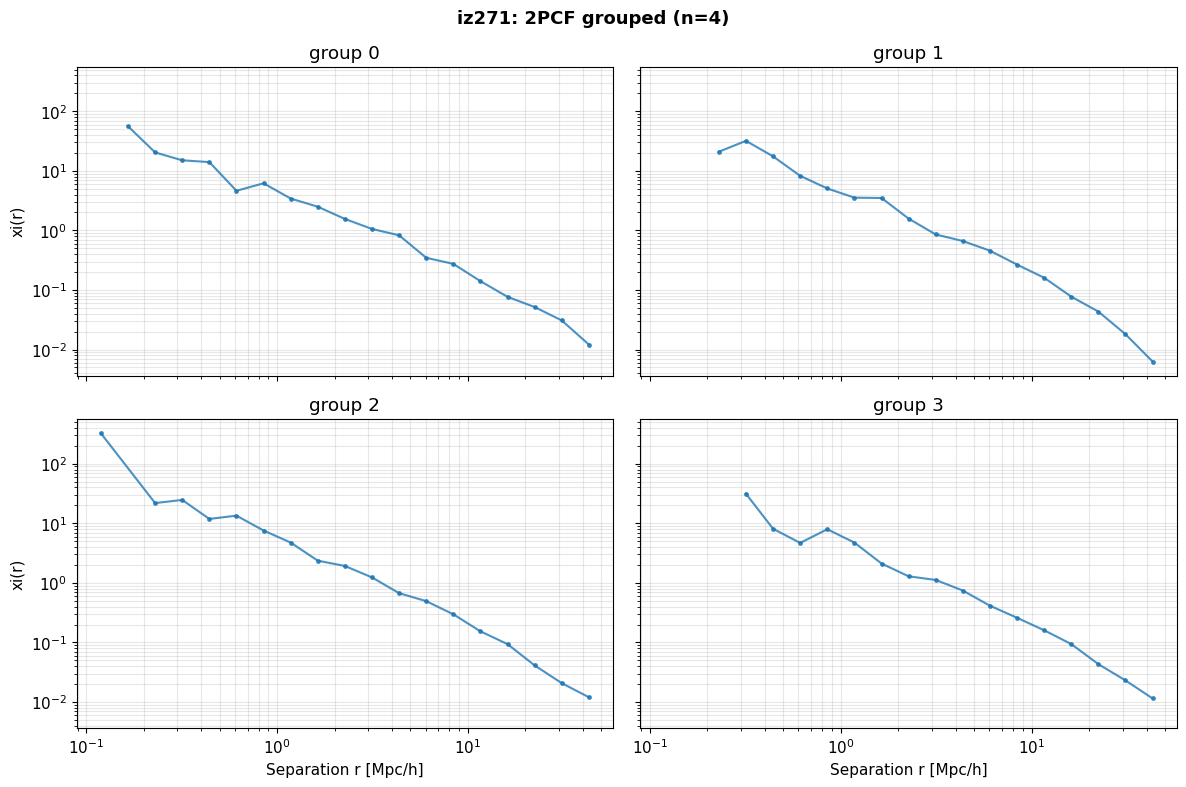

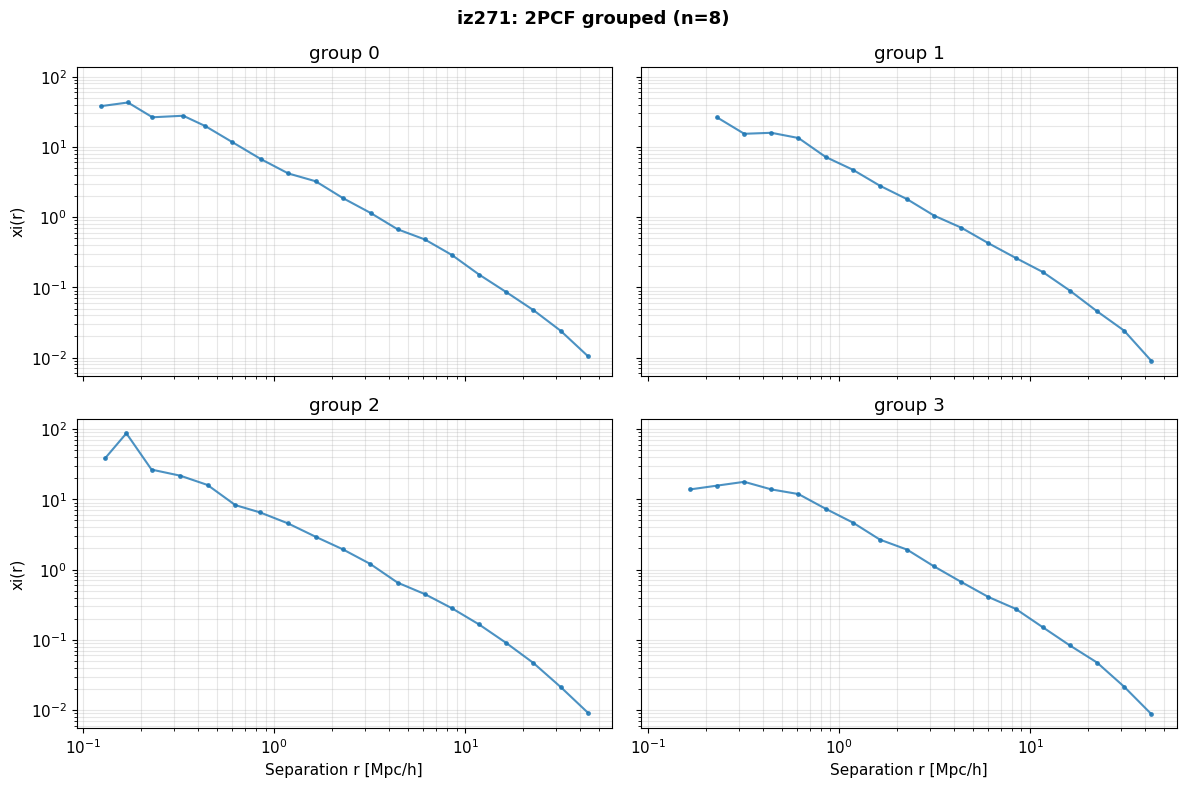

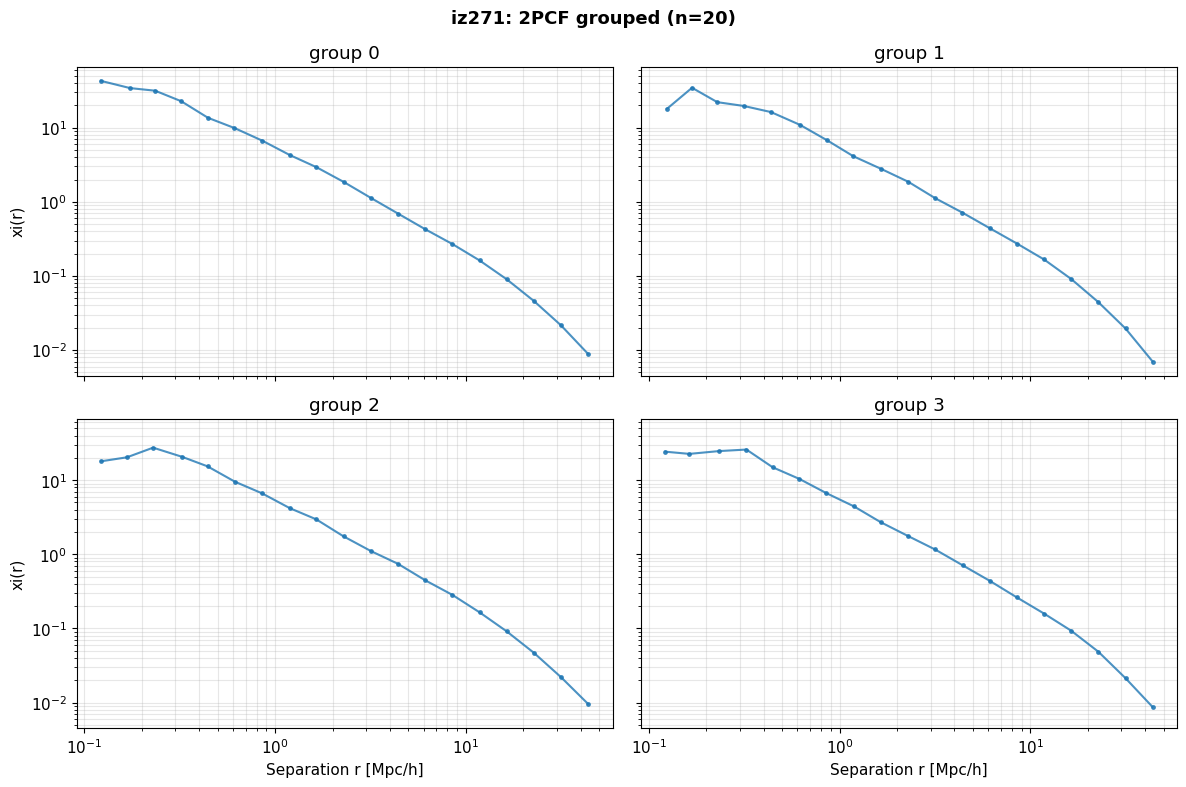

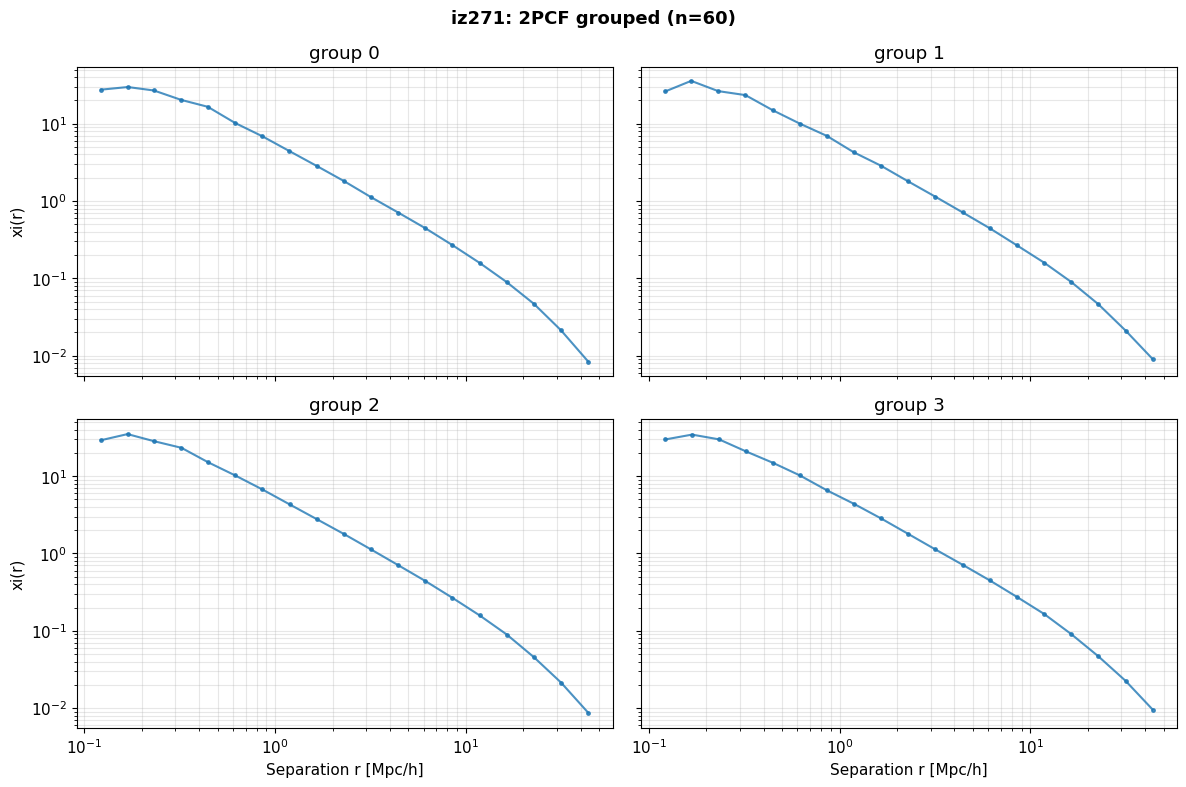

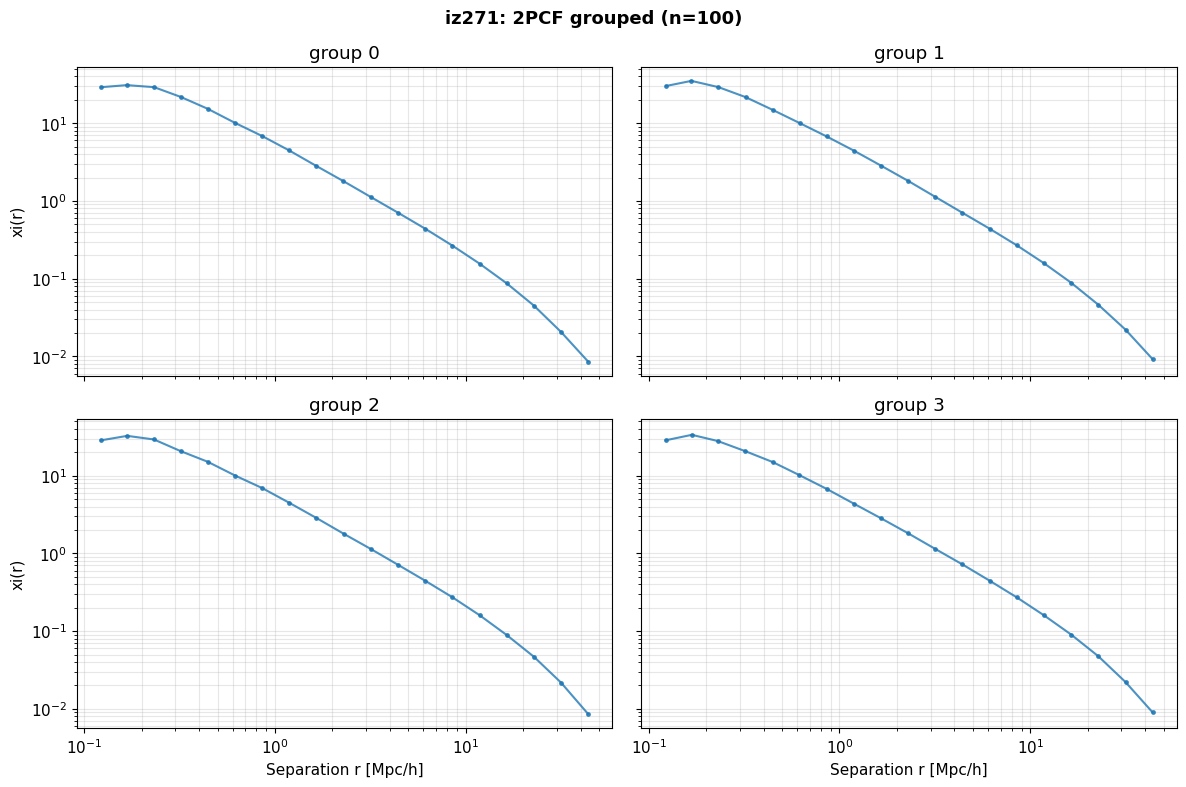

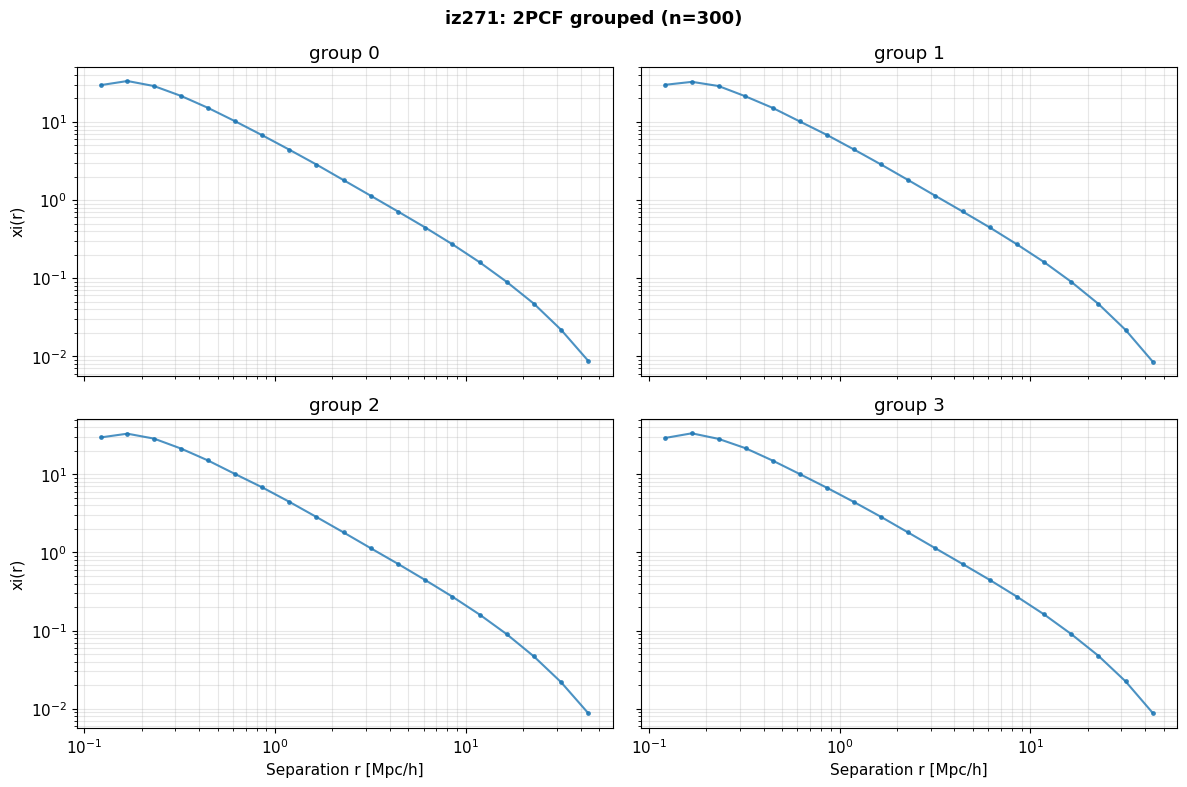

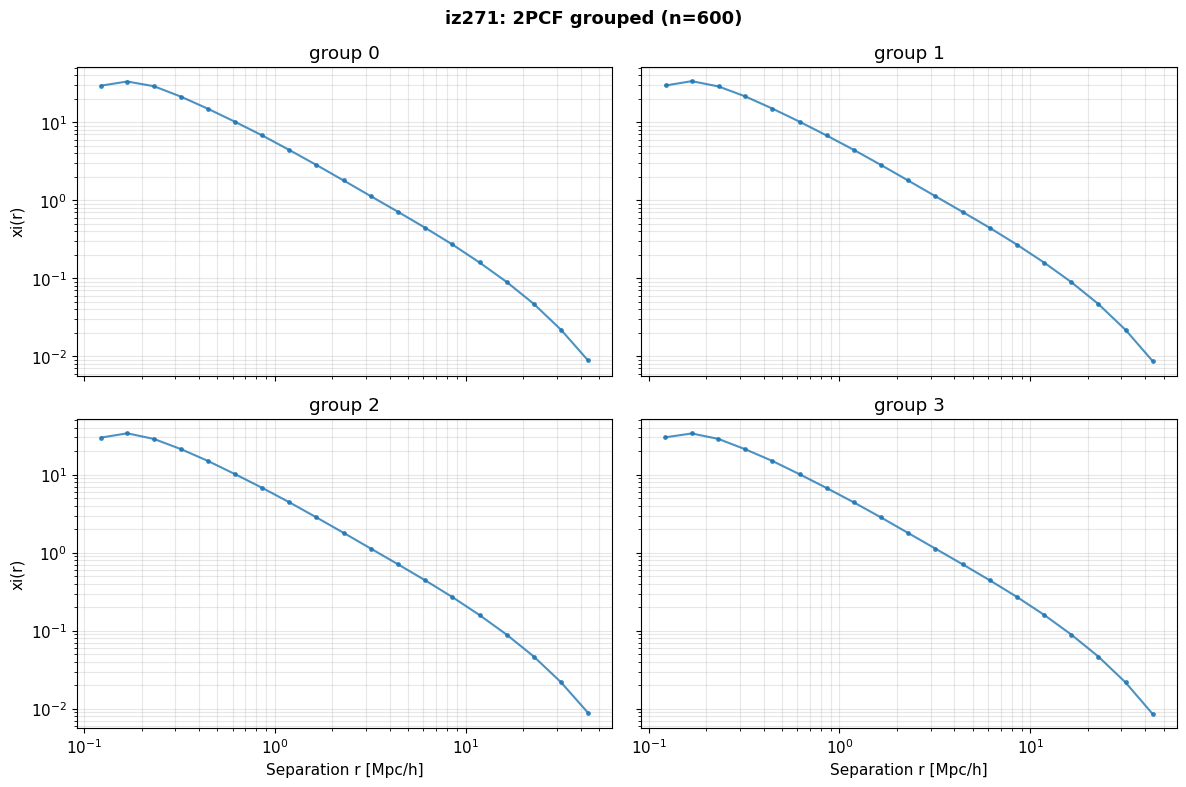

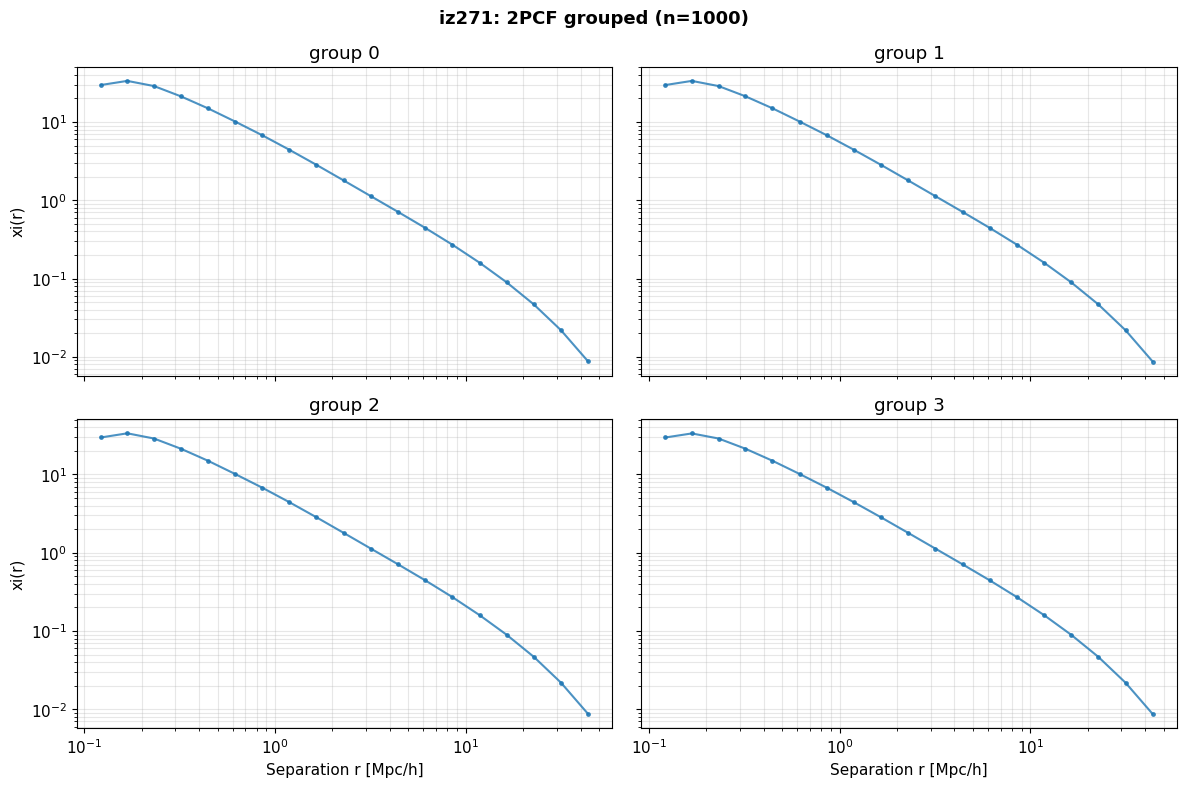

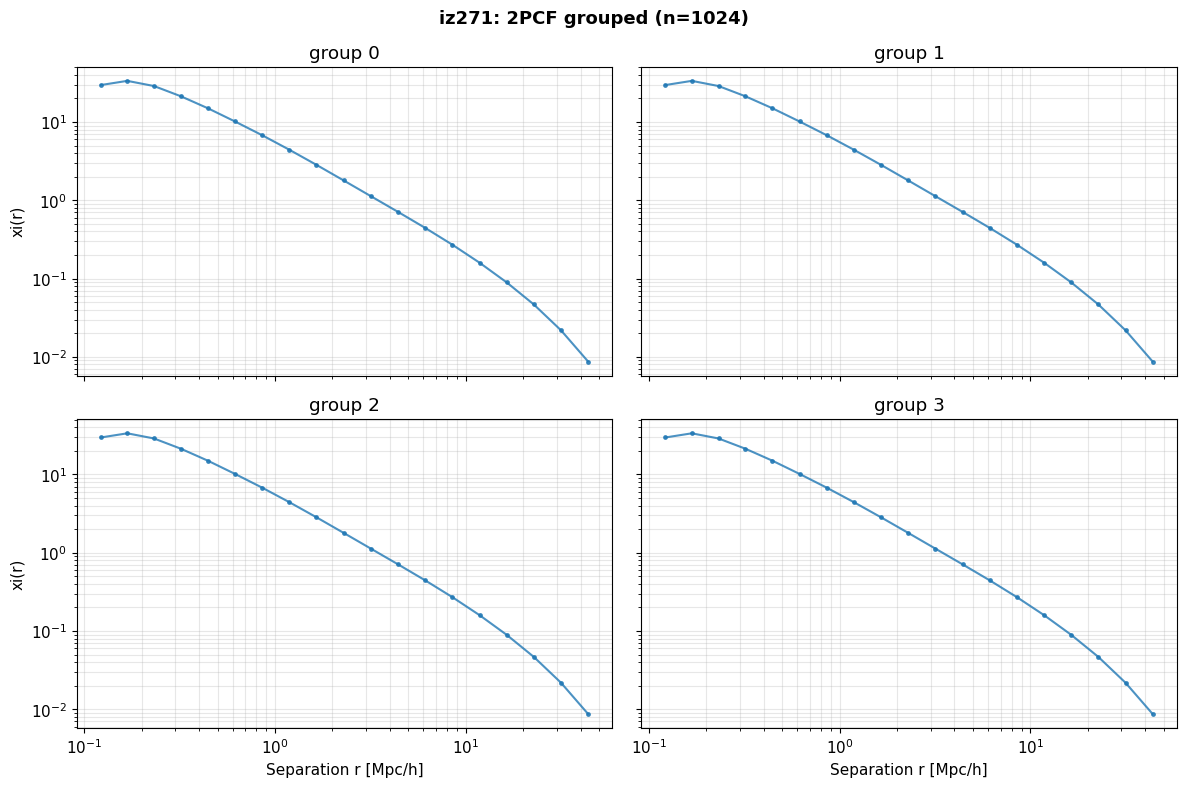

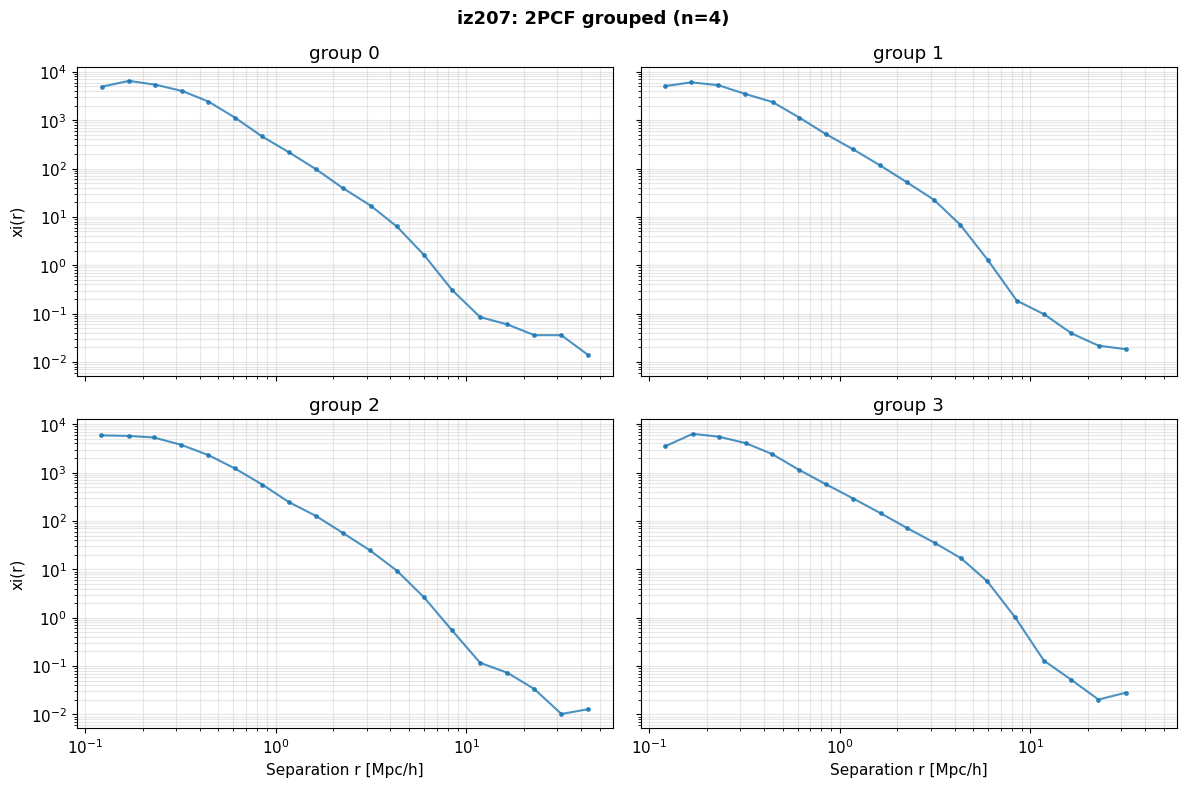

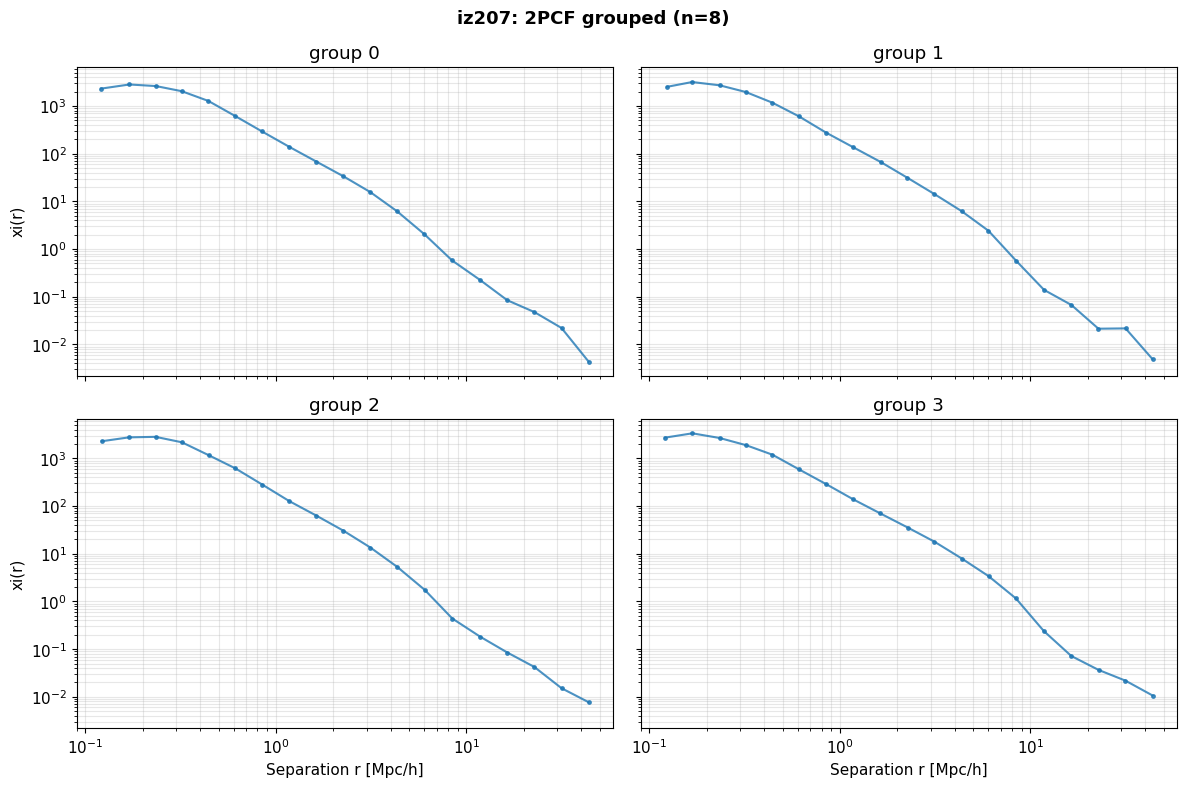

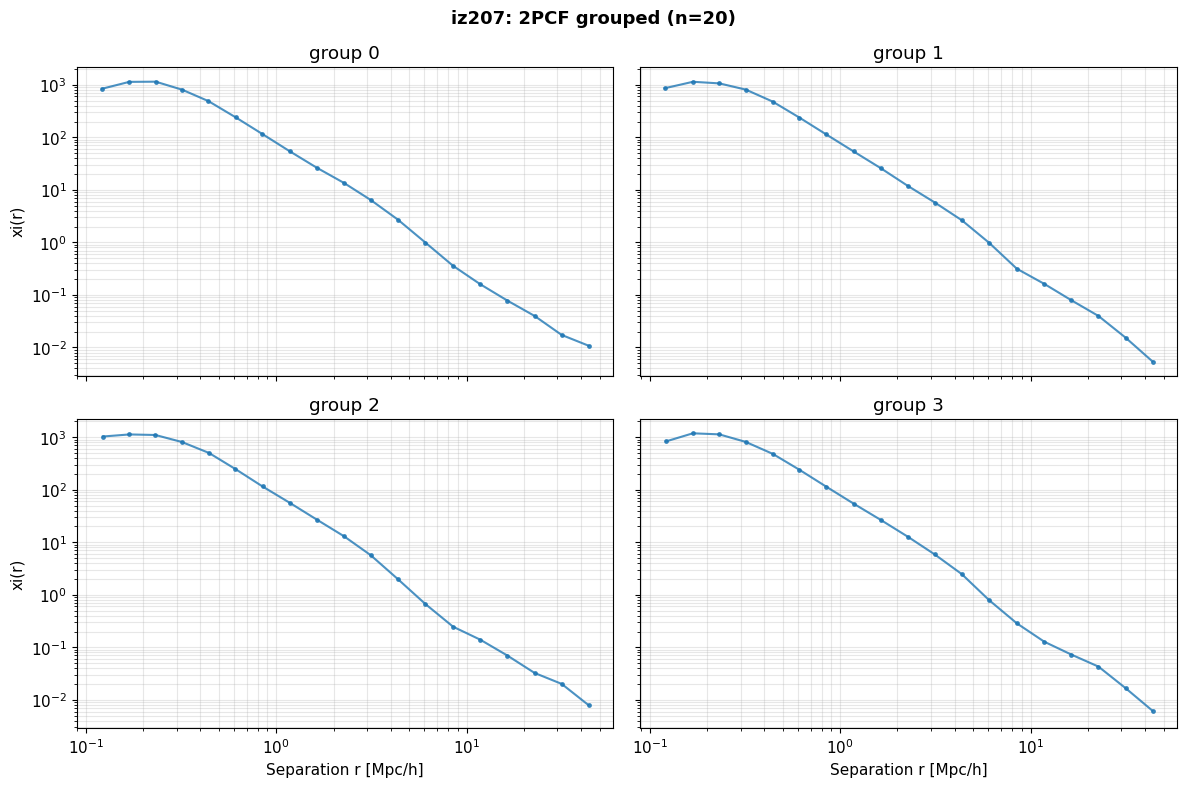

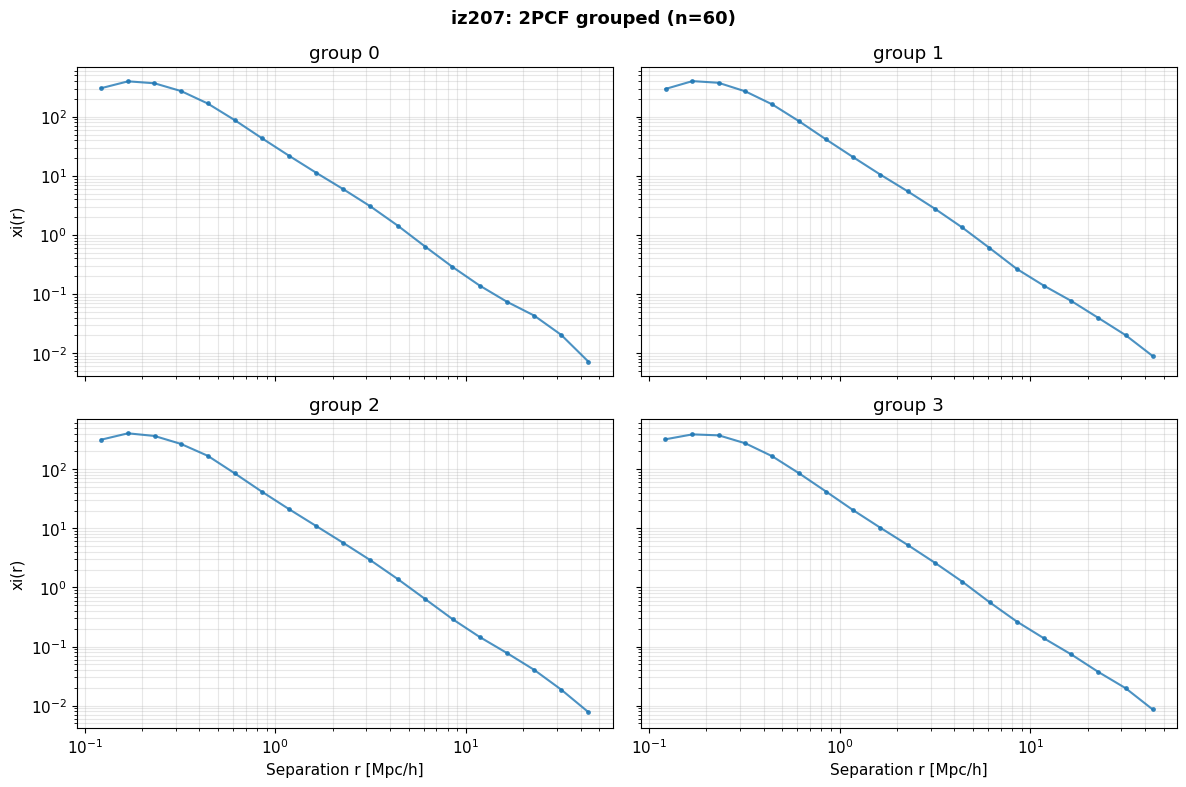

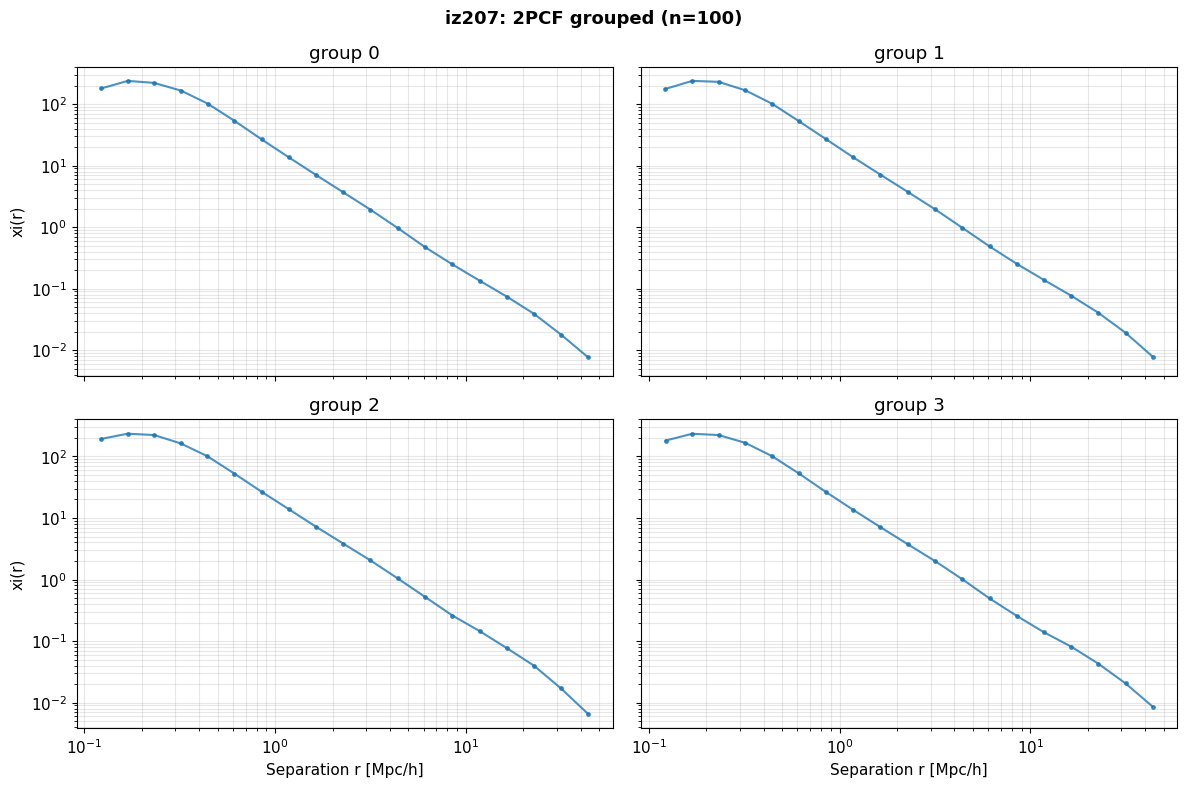

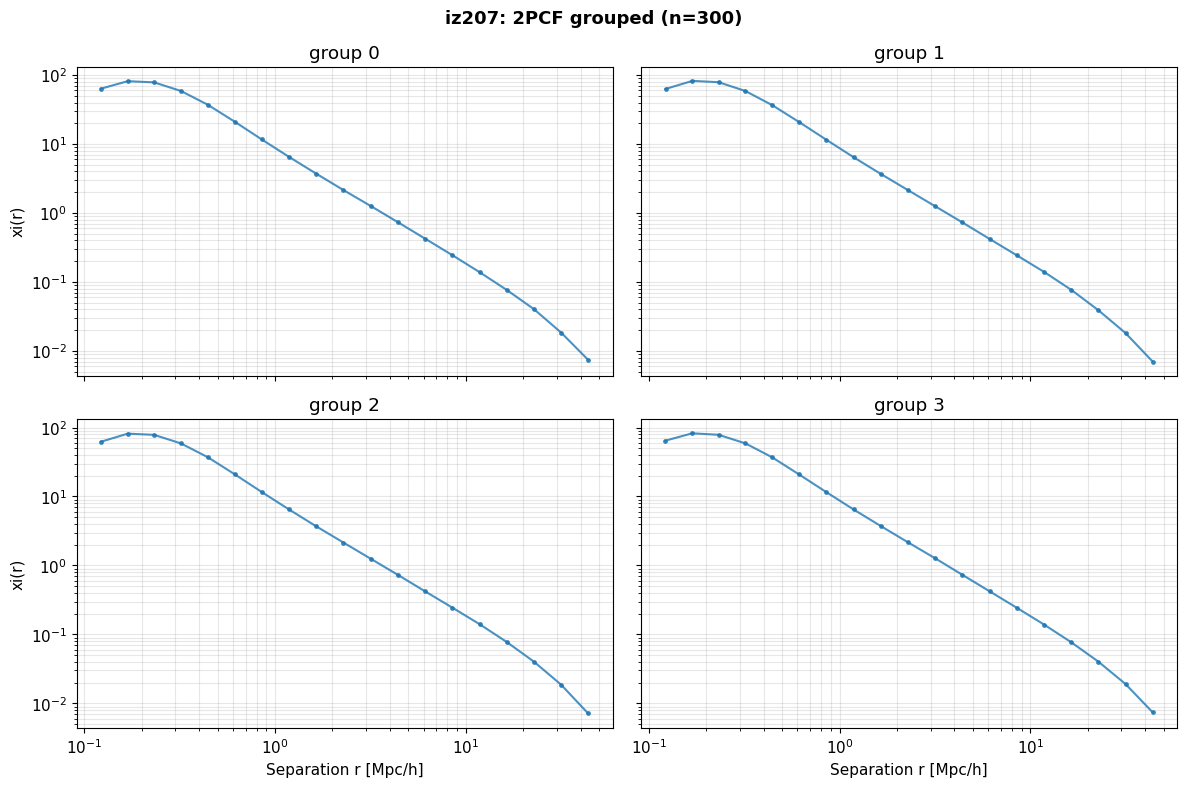

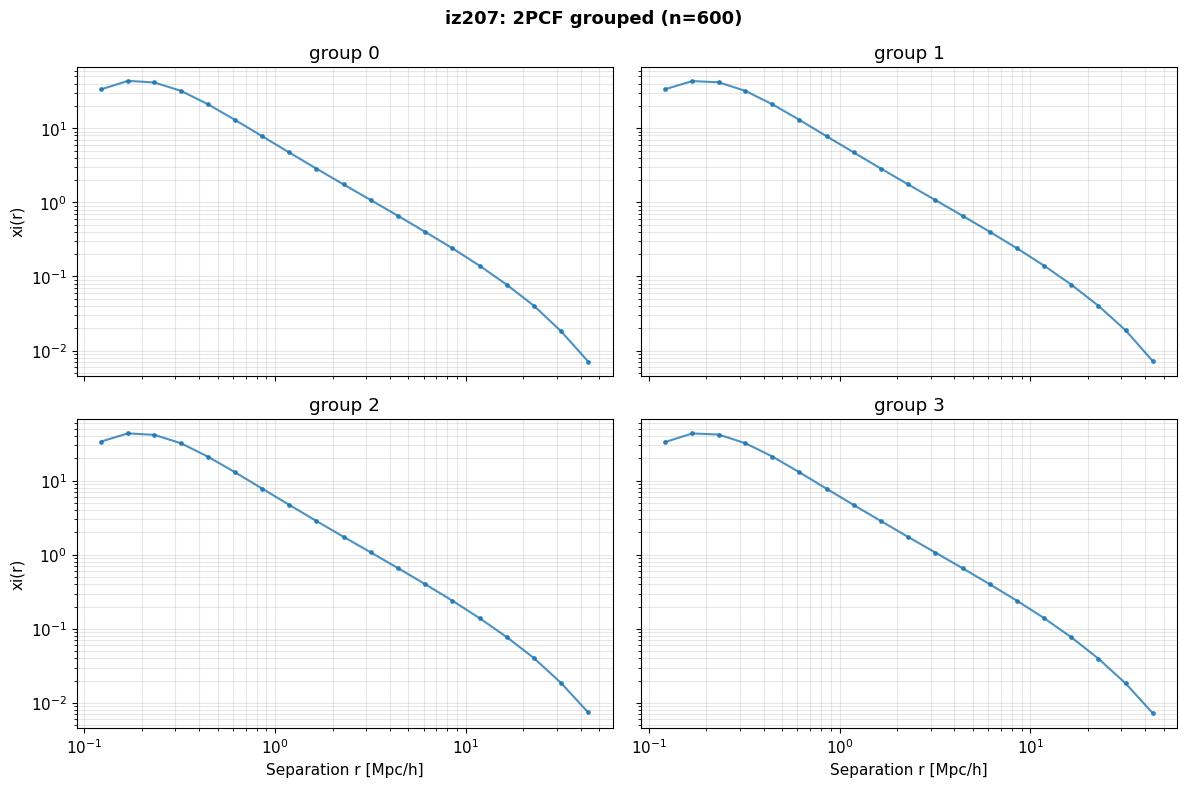

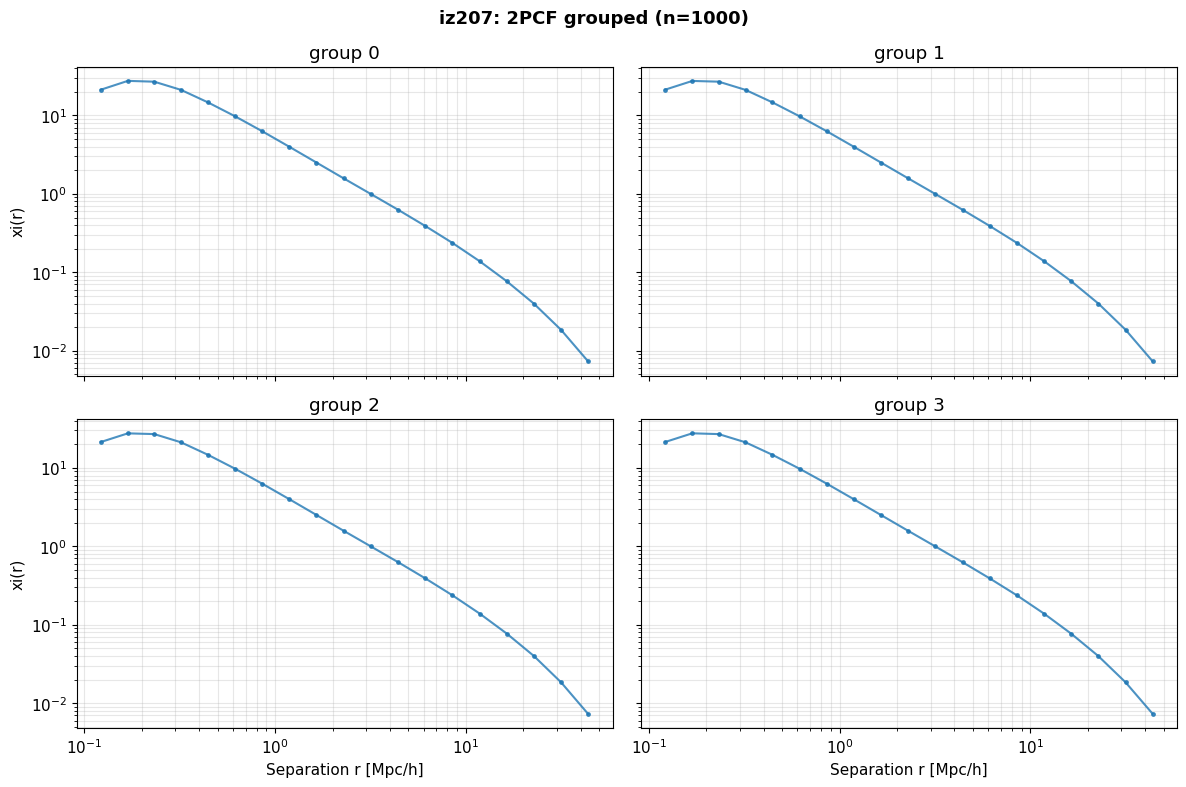

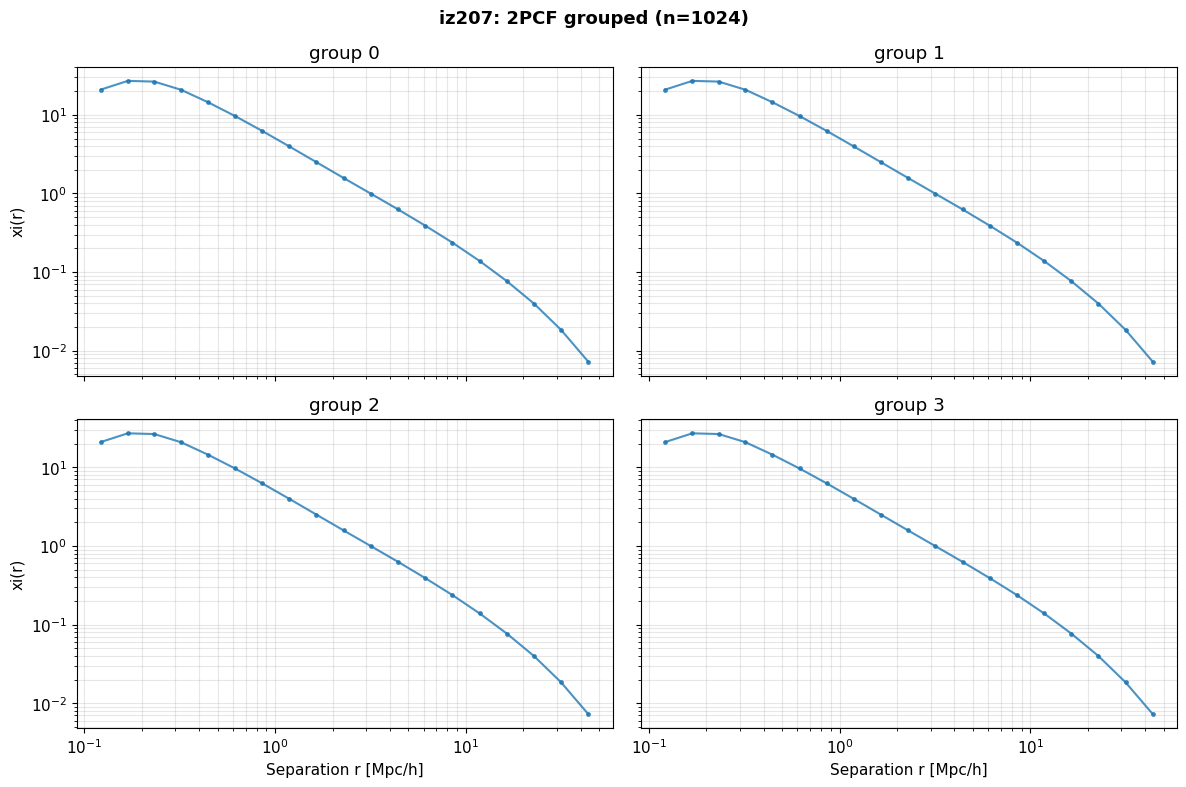

In [18]:
corr_iz271 = pd.read_csv(workspace_root / 'convergence_results_4' / 'corr_convergence_iz271.csv')
corr_iz207 = pd.read_csv(workspace_root / 'convergence_results_4' / 'corr_convergence_iz207.csv')

def plot_grouped_corr(corr_df, iz_label, max_groups=4):
    if 'group_id' not in corr_df.columns:
        print(f"No group_id column found for {iz_label}")
        return
    group_ids = sorted(corr_df['group_id'].unique())[:max_groups]
    n_ivols_list = sorted(corr_df['n_ivols'].unique())
    for n_ivol in n_ivols_list:
        if n_ivol < 4:
            continue
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
        fig.suptitle(f"{iz_label}: 2PCF grouped (n={n_ivol})", fontsize=13, fontweight='bold')
        for ax, group_id in zip(axes.ravel(), group_ids):
            subset = corr_df[(corr_df['n_ivols'] == n_ivol) & (corr_df['group_id'] == group_id)].sort_values('r')
            if subset.empty:
                ax.set_title(f"group {group_id} (no data)")
                ax.axis('off')
                continue
            valid_idx = subset['xi'] > 0
            ax.loglog(subset.loc[valid_idx, 'r'], subset.loc[valid_idx, 'xi'], marker='o', markersize=2.5,
                      linewidth=1.5, alpha=0.8)
            ax.set_title(f"group {group_id}")
            ax.grid(True, alpha=0.3, which='both')
        for ax in axes[-1, :]:
            ax.set_xlabel('Separation r [Mpc/h]')
        for ax in axes[:, 0]:
            ax.set_ylabel('xi(r)')
        plt.tight_layout()
        plt.show()

plot_grouped_corr(corr_iz271, 'iz271')
plot_grouped_corr(corr_iz207, 'iz207')

## Same plot, different mass cut

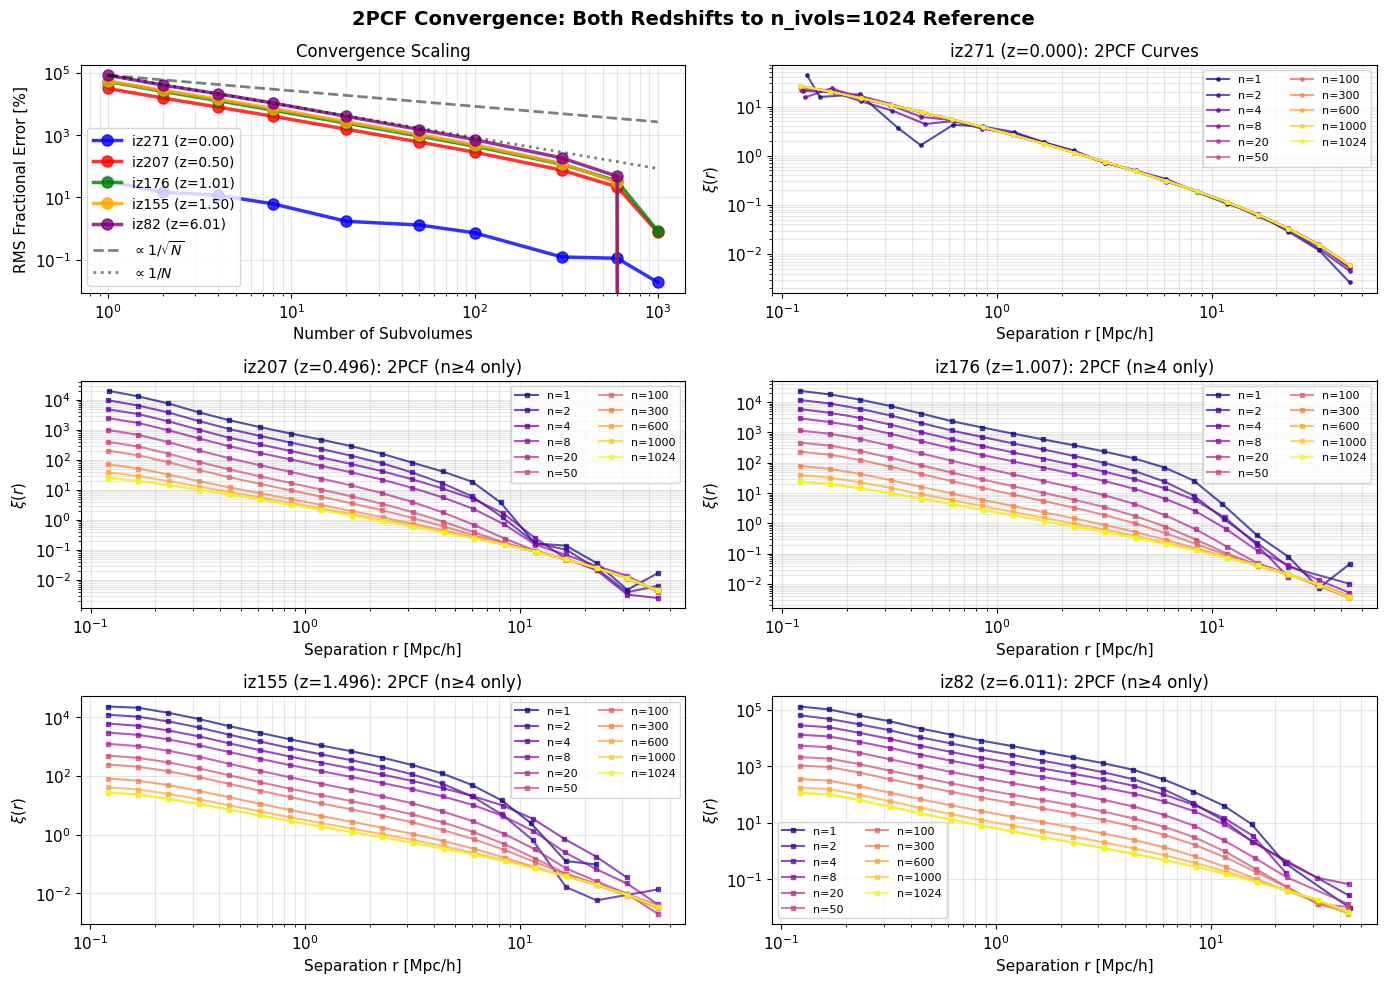

In [4]:
corr_iz271 = pd.read_csv(workspace_root / 'convergence_results_mhalo1e10' / 'corr_convergence_iz271.csv')
corr_iz207 = pd.read_csv(workspace_root / 'convergence_results_mhalo1e10' / 'corr_convergence_iz207.csv')
corr_iz176 = pd.read_csv(workspace_root / 'convergence_results_mhalo1e10' / 'corr_convergence_iz176.csv')
corr_iz155 = pd.read_csv(workspace_root / 'convergence_results_mhalo1e10' / 'corr_convergence_iz155.csv')
corr_iz82 = pd.read_csv(workspace_root / 'convergence_results_mhalo1e10' / 'corr_convergence_iz82.csv')


# Create convergence plots with both redshifts overlaid
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('2PCF Convergence: Both Redshifts to n_ivols=1024 Reference', fontsize=14, fontweight='bold')

redshift_data_corr = [(corr_iz271, 'iz271', 'blue'), (corr_iz207, 'iz207', 'red'), (corr_iz176, 'iz176', 'green'), (corr_iz155, 'iz155', 'orange'), (corr_iz82, 'iz82', 'purple')]

# Subplot 1: Convergence metric (both redshifts overlaid)
ax = axes[0, 0]
for corr_data, iz_label, color in redshift_data_corr:
    corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
    n_ivols_list = sorted(corr_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
        ref_xi = corr_ref['xi'].values
        corr_xi = corr_subset['xi'].values
        valid = (ref_xi != 0) & np.isfinite(ref_xi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    ax.loglog(conv_df['n_ivols'], conv_df['rms_diff'], marker='o', markersize=8, 
              color=color, linewidth=2.5, label=f'{iz_label} (z={corr_data["z"].iloc[0]:.2f})', alpha=0.8)

n_ref_plot = conv_df['n_ivols'].values
rms_ref_plot = conv_df['rms_diff'].iloc[0]
ax.loglog(n_ref_plot, rms_ref_plot * np.sqrt(n_ref_plot[0] / n_ref_plot), 'k--', linewidth=2, 
          label=r'$\propto 1/\sqrt{N}$', alpha=0.5)
ax.loglog(n_ref_plot, rms_ref_plot * n_ref_plot[0] / n_ref_plot, 'k:', linewidth=2, 
          label=r'$\propto 1/N$', alpha=0.5)
ax.set_xlabel('Number of Subvolumes', fontsize=11)
ax.set_ylabel('RMS Fractional Error [%]', fontsize=11)
ax.set_title('Convergence Scaling', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 2: 2PCF curves (iz271)
ax = axes[0, 1]
corr_data = corr_iz271
n_ivols_list = sorted(corr_data['n_ivols'].unique())
colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='o', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz271 (z={corr_iz271["z"].iloc[0]:.3f}): 2PCF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 3: 2PCF curves (iz207) -
ax = axes[1, 0]
corr_data = corr_iz207
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz207 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz207 (z={corr_iz207["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


#Subplot 4: 2PCF curves (iz176) 
ax = axes[1, 1]
corr_data = corr_iz176
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz176 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz176 (z={corr_iz176["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


#Subplot 5: 2PCF curves (iz155) 
ax = axes[2, 0]
corr_data = corr_iz155
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz155 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz155 (z={corr_iz155["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

#Subplot 6: 2PCF curves (iz82) 
ax = axes[2, 1]
corr_data = corr_iz82
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz82 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz82 (z={corr_iz82["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


# # Subplot 7: Statistics table
# ax = axes[1, 1]
# ax.axis('off')
# stats_text = "RMS Error Statistics:\n\n"
# for corr_data, iz_label, _ in redshift_data_corr:
#     corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
#     n_ivols_list = sorted(corr_data['n_ivols'].unique())
#     convergence_metric = []
#     for n_ivol in n_ivols_list[:-1]:
#         corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
#         ref_xi = corr_ref['xi'].values
#         corr_xi = corr_subset['xi'].values
#         valid = (ref_xi != 0) & np.isfinite(ref_xi)
#         if valid.sum() > 0:
#             rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
#         else:
#             rms_diff = np.nan
#         convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
#     conv_df = pd.DataFrame(convergence_metric).dropna()
#     stats_text += f"{iz_label} (z={corr_data['z'].iloc[0]:.3f}):\n"
#     for idx, row in conv_df.iterrows():
#         stats_text += f"  n={int(row['n_ivols']):4d}: {row['rms_diff']:6.2f}%\n"
#     stats_text += "\n"
# ax.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
#         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## rerun to be sure 1e11 mass cut

In [14]:
corr_iz271 = pd.read_csv(workspace_root / 'convergence_results_2' / 'corr_convergence_iz271.csv')
corr_iz207 = pd.read_csv(workspace_root / 'convergence_results_2' / 'corr_convergence_iz207.csv')
corr_iz176 = pd.read_csv(workspace_root / 'convergence_results_2' / 'corr_convergence_iz176.csv')
corr_iz155 = pd.read_csv(workspace_root / 'convergence_results_2' / 'corr_convergence_iz155.csv')
corr_iz82 = pd.read_csv(workspace_root / 'convergence_results_2' / 'corr_convergence_iz82.csv')


# Create convergence plots with both redshifts overlaid
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('2PCF Convergence: Both Redshifts to n_ivols=1024 Reference', fontsize=14, fontweight='bold')

redshift_data_corr = [(corr_iz271, 'iz271', 'blue'), (corr_iz207, 'iz207', 'red'), (corr_iz176, 'iz176', 'green'), (corr_iz155, 'iz155', 'orange'), (corr_iz82, 'iz82', 'purple')]

# Subplot 1: Convergence metric (both redshifts overlaid)
ax = axes[0, 0]
for corr_data, iz_label, color in redshift_data_corr:
    corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
    n_ivols_list = sorted(corr_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
        ref_xi = corr_ref['xi'].values
        corr_xi = corr_subset['xi'].values
        valid = (ref_xi != 0) & np.isfinite(ref_xi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    ax.loglog(conv_df['n_ivols'], conv_df['rms_diff'], marker='o', markersize=8, 
              color=color, linewidth=2.5, label=f'{iz_label} (z={corr_data["z"].iloc[0]:.2f})', alpha=0.8)

n_ref_plot = conv_df['n_ivols'].values
rms_ref_plot = conv_df['rms_diff'].iloc[0]
ax.loglog(n_ref_plot, rms_ref_plot * np.sqrt(n_ref_plot[0] / n_ref_plot), 'k--', linewidth=2, 
          label=r'$\propto 1/\sqrt{N}$', alpha=0.5)
ax.loglog(n_ref_plot, rms_ref_plot * n_ref_plot[0] / n_ref_plot, 'k:', linewidth=2, 
          label=r'$\propto 1/N$', alpha=0.5)
ax.set_xlabel('Number of Subvolumes', fontsize=11)
ax.set_ylabel('RMS Fractional Error [%]', fontsize=11)
ax.set_title('Convergence Scaling', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 2: 2PCF curves (iz271)
ax = axes[0, 1]
corr_data = corr_iz271
n_ivols_list = sorted(corr_data['n_ivols'].unique())
colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='o', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz271 (z={corr_iz271["z"].iloc[0]:.3f}): 2PCF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 3: 2PCF curves (iz207) -
ax = axes[1, 0]
corr_data = corr_iz207
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz207 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz207 (z={corr_iz207["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


#Subplot 4: 2PCF curves (iz176) 
ax = axes[1, 1]
corr_data = corr_iz176
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz176 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz176 (z={corr_iz176["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


#Subplot 5: 2PCF curves (iz155) 
ax = axes[2, 0]
corr_data = corr_iz155
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz155 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz155 (z={corr_iz155["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

#Subplot 6: 2PCF curves (iz82) 
ax = axes[2, 1]
corr_data = corr_iz82
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz82 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz82 (z={corr_iz82["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


# # Subplot 7: Statistics table
# ax = axes[1, 1]
# ax.axis('off')
# stats_text = "RMS Error Statistics:\n\n"
# for corr_data, iz_label, _ in redshift_data_corr:
#     corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
#     n_ivols_list = sorted(corr_data['n_ivols'].unique())
#     convergence_metric = []
#     for n_ivol in n_ivols_list[:-1]:
#         corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
#         ref_xi = corr_ref['xi'].values
#         corr_xi = corr_subset['xi'].values
#         valid = (ref_xi != 0) & np.isfinite(ref_xi)
#         if valid.sum() > 0:
#             rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
#         else:
#             rms_diff = np.nan
#         convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
#     conv_df = pd.DataFrame(convergence_metric).dropna()
#     stats_text += f"{iz_label} (z={corr_data['z'].iloc[0]:.3f}):\n"
#     for idx, row in conv_df.iterrows():
#         stats_text += f"  n={int(row['n_ivols']):4d}: {row['rms_diff']:6.2f}%\n"
#     stats_text += "\n"
# ax.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
#         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/cosma/home/durham/dc-hick2/galform_analysis/convergence_results_2/corr_convergence_iz176.csv'

## same plot, all galaxies not just centrals

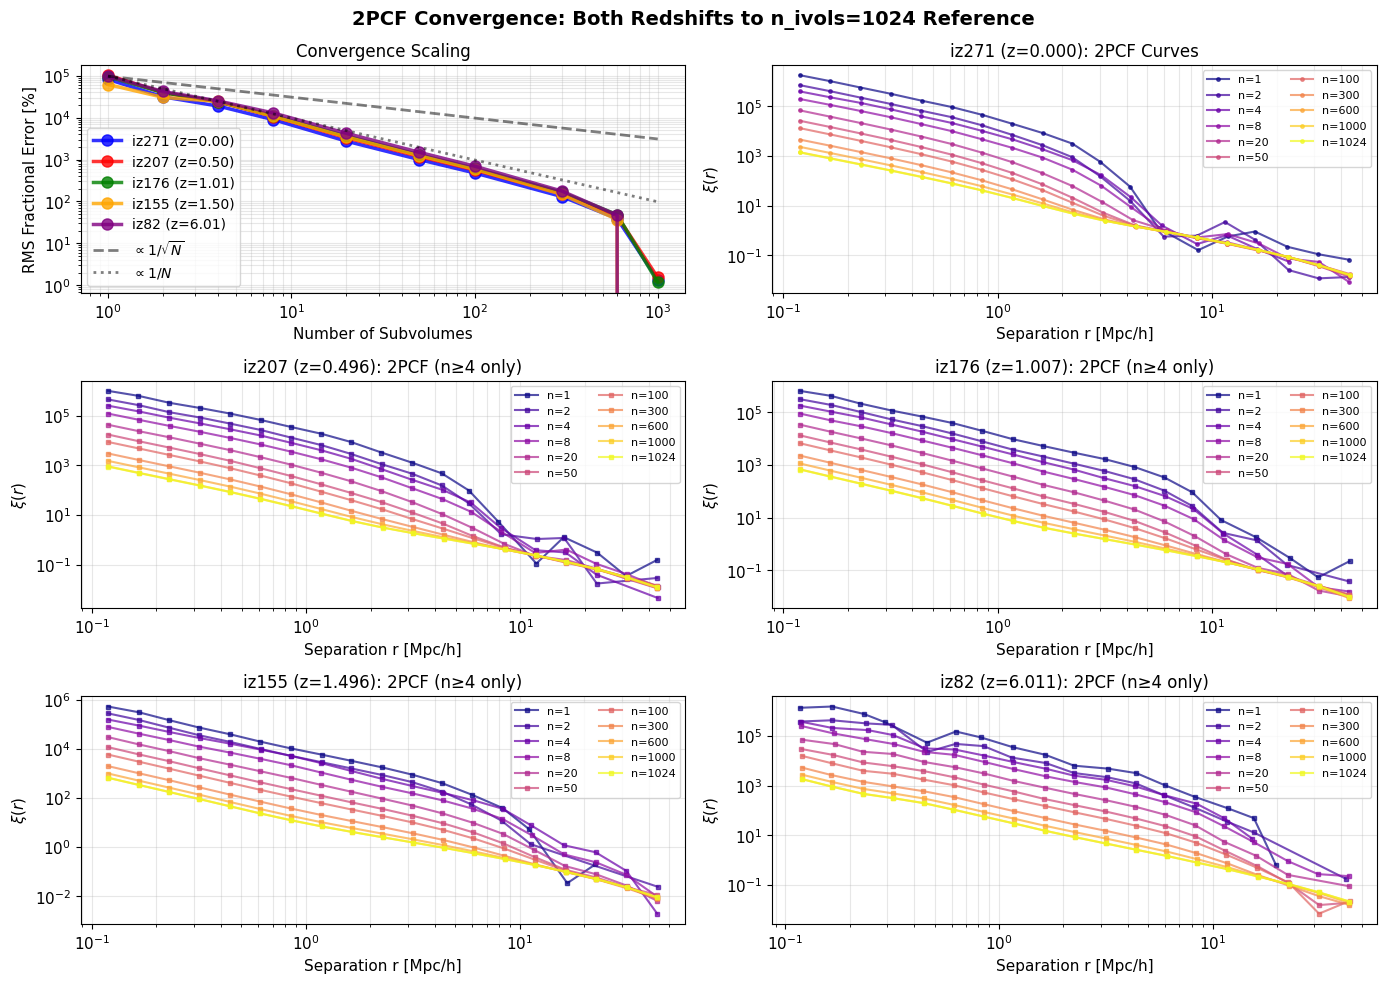

In [6]:
corr_iz271 = pd.read_csv(workspace_root / 'convergence_results_corr_allgal' / 'corr_convergence_iz271.csv')
corr_iz207 = pd.read_csv(workspace_root / 'convergence_results_corr_allgal' / 'corr_convergence_iz207.csv')
corr_iz176 = pd.read_csv(workspace_root / 'convergence_results_corr_allgal' / 'corr_convergence_iz176.csv')
corr_iz155 = pd.read_csv(workspace_root / 'convergence_results_corr_allgal' / 'corr_convergence_iz155.csv')
corr_iz82 = pd.read_csv(workspace_root / 'convergence_results_corr_allgal' / 'corr_convergence_iz82.csv')


# Create convergence plots with both redshifts overlaid
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('2PCF Convergence: Both Redshifts to n_ivols=1024 Reference', fontsize=14, fontweight='bold')

redshift_data_corr = [(corr_iz271, 'iz271', 'blue'), (corr_iz207, 'iz207', 'red'), (corr_iz176, 'iz176', 'green'), (corr_iz155, 'iz155', 'orange'), (corr_iz82, 'iz82', 'purple')]

# Subplot 1: Convergence metric (both redshifts overlaid)
ax = axes[0, 0]
for corr_data, iz_label, color in redshift_data_corr:
    corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
    n_ivols_list = sorted(corr_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
        ref_xi = corr_ref['xi'].values
        corr_xi = corr_subset['xi'].values
        valid = (ref_xi != 0) & np.isfinite(ref_xi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    ax.loglog(conv_df['n_ivols'], conv_df['rms_diff'], marker='o', markersize=8, 
              color=color, linewidth=2.5, label=f'{iz_label} (z={corr_data["z"].iloc[0]:.2f})', alpha=0.8)

n_ref_plot = conv_df['n_ivols'].values
rms_ref_plot = conv_df['rms_diff'].iloc[0]
ax.loglog(n_ref_plot, rms_ref_plot * np.sqrt(n_ref_plot[0] / n_ref_plot), 'k--', linewidth=2, 
          label=r'$\propto 1/\sqrt{N}$', alpha=0.5)
ax.loglog(n_ref_plot, rms_ref_plot * n_ref_plot[0] / n_ref_plot, 'k:', linewidth=2, 
          label=r'$\propto 1/N$', alpha=0.5)
ax.set_xlabel('Number of Subvolumes', fontsize=11)
ax.set_ylabel('RMS Fractional Error [%]', fontsize=11)
ax.set_title('Convergence Scaling', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 2: 2PCF curves (iz271)
ax = axes[0, 1]
corr_data = corr_iz271
n_ivols_list = sorted(corr_data['n_ivols'].unique())
colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='o', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz271 (z={corr_iz271["z"].iloc[0]:.3f}): 2PCF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 3: 2PCF curves (iz207) -
ax = axes[1, 0]
corr_data = corr_iz207
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz207 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz207 (z={corr_iz207["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


#Subplot 4: 2PCF curves (iz176) 
ax = axes[1, 1]
corr_data = corr_iz176
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz176 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz176 (z={corr_iz176["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


#Subplot 5: 2PCF curves (iz155) 
ax = axes[2, 0]
corr_data = corr_iz155
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz155 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz155 (z={corr_iz155["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

#Subplot 6: 2PCF curves (iz82) 
ax = axes[2, 1]
corr_data = corr_iz82
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz82 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz82 (z={corr_iz82["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
# ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
#         transform=ax.transAxes, fontsize=9, va='top', 
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))


# # Subplot 7: Statistics table
# ax = axes[1, 1]
# ax.axis('off')
# stats_text = "RMS Error Statistics:\n\n"
# for corr_data, iz_label, _ in redshift_data_corr:
#     corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
#     n_ivols_list = sorted(corr_data['n_ivols'].unique())
#     convergence_metric = []
#     for n_ivol in n_ivols_list[:-1]:
#         corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
#         ref_xi = corr_ref['xi'].values
#         corr_xi = corr_subset['xi'].values
#         valid = (ref_xi != 0) & np.isfinite(ref_xi)
#         if valid.sum() > 0:
#             rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
#         else:
#             rms_diff = np.nan
#         convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
#     conv_df = pd.DataFrame(convergence_metric).dropna()
#     stats_text += f"{iz_label} (z={corr_data['z'].iloc[0]:.3f}):\n"
#     for idx, row in conv_df.iterrows():
#         stats_text += f"  n={int(row['n_ivols']):4d}: {row['rms_diff']:6.2f}%\n"
#     stats_text += "\n"
# ax.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
#         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## Understanding Pair Counts (DD)

In [2]:
# Extract pair counts (DD) from multiple n values
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

pair_counts_data = []
base_dir_path = Path(get_base_dir())

for iz_num in [271, 207, 176]:
    iz_name = f"iz{iz_num}"
    print(f"\n{iz_name}:")
    
    boxsize = 542.158
    r_target = 2.0
    mass_cut = 1e9
    for n in [1, 2, 4, 8, 20, 50, 100]:
        
        all_pos = []
        iz_path = str(base_dir_path / iz_name)
        for ivol in range(n):
            try:
                pos, _ = _load_positions_from_hdf5(iz_path, ivol+100, centrals_only=True, mhalo_min=mass_cut)
                all_pos.append(pos)
            except (FileNotFoundError, KeyError):
                print("fail")
                print("FileNotFoundError")
                continue
        
        if not all_pos:
            continue
            
        combined_pos = np.vstack(all_pos)
        ngal = len(combined_pos)
        
        
        rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
        results = corrfunc_xi(
            boxsize=boxsize,
            nthreads=16,
            binfile=rbins_test,
            X=combined_pos[:, 0],
            Y=combined_pos[:, 1],
            Z=combined_pos[:, 2],
            output_ravg=True,
        )
        
        dd = None
        for res in results:
            if res['ravg'] >= r_target:
                dd = int(res['npairs'])
                break
        
        if dd is not None:
            pair_counts_data.append({
                'iz': iz_name,
                'n': n,
                'ngal': ngal,
                'dd_actual': dd,
            })
            
            print(f"  n={n:3d}: N_gal={ngal:10d}, DD(r={r_target})={dd:10d}")

pair_counts_df = pd.DataFrame(pair_counts_data)
print("\n" + "="*70)
print("Pair Counts Summary:")
print(pair_counts_df)



iz271:
  n=  1: N_gal=     71415, DD(r=2.0)=      2402
  n=  2: N_gal=    142969, DD(r=2.0)=      9432
  n=  4: N_gal=    286337, DD(r=2.0)=     37672
  n=  8: N_gal=    572542, DD(r=2.0)=    150598
  n= 20: N_gal=   1430815, DD(r=2.0)=    939810
  n= 50: N_gal=   3575085, DD(r=2.0)=   5868632
  n=100: N_gal=   7150608, DD(r=2.0)=  23446514

iz207:
  n=  1: N_gal=     95668, DD(r=2.0)=    207272
  n=  2: N_gal=    192312, DD(r=2.0)=    479536
  n=  4: N_gal=    388797, DD(r=2.0)=   1203572
  n=  8: N_gal=    781295, DD(r=2.0)=   2933602
  n= 20: N_gal=   1950836, DD(r=2.0)=   8129242
  n= 50: N_gal=   4848147, DD(r=2.0)=  23591024
  n=100: N_gal=   9698133, DD(r=2.0)=  63937726

iz176:
  n=  1: N_gal=    120691, DD(r=2.0)=    632652
  n=  2: N_gal=    243280, DD(r=2.0)=   1479232
  n=  4: N_gal=    494363, DD(r=2.0)=   3413384
  n=  8: N_gal=    997463, DD(r=2.0)=   7804526
  n= 20: N_gal=   2489899, DD(r=2.0)=  20528412
  n= 50: N_gal=   6165701, DD(r=2.0)=  53678866
  n=100: N_gal= 

In [5]:
# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207', 'iz176']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"  {'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"  {row['n']:3d} | {row['ngal']:10d} | {row['dd_actual']:10d} | {dd_per_n2:12.4e}")


iz271:
    n |      N_gal |         DD |        DD/N²
    1 |      71415 |       2402 |   4.7097e-07
    2 |     142969 |       9432 |   4.6145e-07
    4 |     286337 |      37672 |   4.5948e-07
    8 |     572542 |     150598 |   4.5941e-07
   20 |    1430815 |     939810 |   4.5906e-07
   50 |    3575085 |    5868632 |   4.5916e-07
  100 |    7150608 |   23446514 |   4.5856e-07

iz207:
    n |      N_gal |         DD |        DD/N²
    1 |      95668 |     207272 |   2.2647e-05
    2 |     192312 |     479536 |   1.2966e-05
    4 |     388797 |    1203572 |   7.9621e-06
    8 |     781295 |    2933602 |   4.8059e-06
   20 |    1950836 |    8129242 |   2.1360e-06
   50 |    4848147 |   23591024 |   1.0037e-06
  100 |    9698133 |   63937726 |   6.7980e-07

iz176:
    n |      N_gal |         DD |        DD/N²
    1 |     120691 |     632652 |   4.3433e-05
    2 |     243280 |    1479232 |   2.4993e-05
    4 |     494363 |    3413384 |   1.3967e-05
    8 |     997463 |    7804526 |   

## DD vs n and DD/N^2 vs n

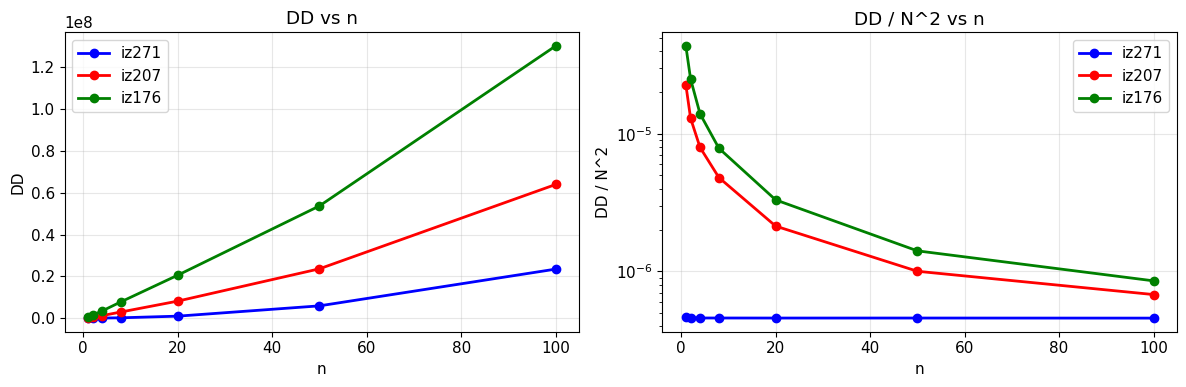

In [6]:
# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red'), ('iz176', 'green')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

## same again, everything, not centrals


iz271:
  n=  1: N_gal=    120081, DD(r=2.0)=    332052
  n=  2: N_gal=    243800, DD(r=2.0)=   2634726
  n=  4: N_gal=    499805, DD(r=2.0)=   7540776
  n=  8: N_gal=   1011502, DD(r=2.0)=  32608476
  n= 20: N_gal=   2526391, DD(r=2.0)=  82567566
  n= 50: N_gal=   6224321, DD(r=2.0)= 208406450
  n=100: N_gal=  12469268, DD(r=2.0)= 465758838

iz207:
  n=  1: N_gal=    144662, DD(r=2.0)=   2313756
  n=  2: N_gal=    294228, DD(r=2.0)=   7079532
  n=  4: N_gal=    603291, DD(r=2.0)=  18259662
  n=  8: N_gal=   1220992, DD(r=2.0)=  48244880
  n= 20: N_gal=   3048880, DD(r=2.0)= 131202600
  n= 50: N_gal=   7512336, DD(r=2.0)= 302368830
  n=100: N_gal=  15049131, DD(r=2.0)= 645517876

iz176:
  n=  1: N_gal=    168539, DD(r=2.0)=   3228574
  n=  2: N_gal=    342991, DD(r=2.0)=   9583100
  n=  4: N_gal=    704461, DD(r=2.0)=  21823326
  n=  8: N_gal=   1426877, DD(r=2.0)=  50194234
  n= 20: N_gal=   3561517, DD(r=2.0)= 131481204
  n= 50: N_gal=   8768246, DD(r=2.0)= 305071008
  n=100: N_gal= 

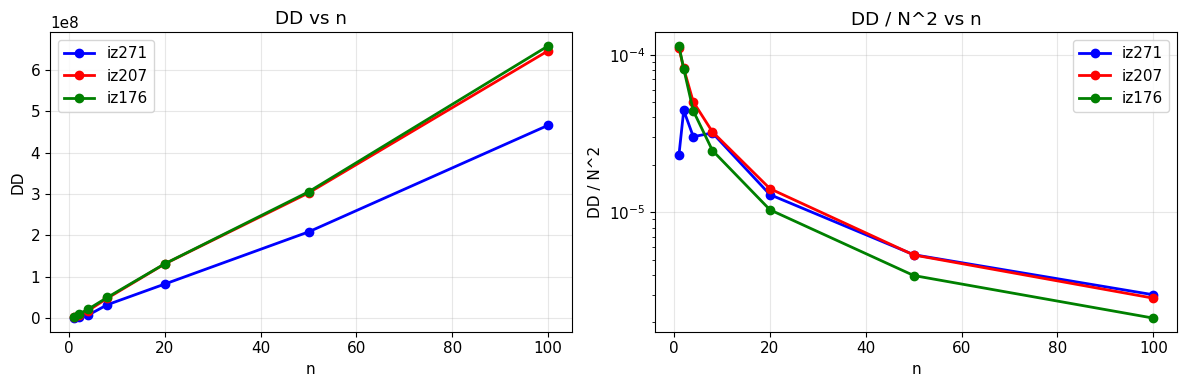

In [7]:
# Extract pair counts (DD) from multiple n values
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

pair_counts_data = []
base_dir_path = Path(get_base_dir())

for iz_num in [271, 207, 176]:
    iz_name = f"iz{iz_num}"
    print(f"\n{iz_name}:")
    mass_cut = 1e9
    boxsize = 542.158
    r_target = 2.0
    for n in [1, 2, 4, 8, 20, 50, 100]:
        
        all_pos = []
        iz_path = str(base_dir_path / iz_name)
        for ivol in range(n):
            try:
                pos, _ = _load_positions_from_hdf5(iz_path, ivol + 100, centrals_only=False, mhalo_min=mass_cut)
                all_pos.append(pos)
            except (FileNotFoundError, KeyError):
                print(f"FileNotFoundError {iz_path}, ivol={ivol}, {KeyError}")
                continue
        
        if not all_pos:
            continue
            
        combined_pos = np.vstack(all_pos)
        ngal = len(combined_pos)
        
        
        rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
        results = corrfunc_xi(
            boxsize=boxsize,
            nthreads=16,
            binfile=rbins_test,
            X=combined_pos[:, 0],
            Y=combined_pos[:, 1],
            Z=combined_pos[:, 2],
            output_ravg=True,
        )
        
        dd = None
        for res in results:
            if res['ravg'] >= r_target:
                dd = int(res['npairs'])
                break
        
        if dd is not None:
            pair_counts_data.append({
                'iz': iz_name,
                'n': n,
                'ngal': ngal,
                'dd_actual': dd,
            })
            
            print(f"  n={n:3d}: N_gal={ngal:10d}, DD(r={r_target})={dd:10d}")

pair_counts_df = pd.DataFrame(pair_counts_data)
print("\n" + "="*70)
print("Pair Counts Summary:")
print(pair_counts_df)


####

# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207', 'iz176']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"{'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"{row['n']:3d} | {row['ngal']:10d} | {row['dd_actual']:10d} | {dd_per_n2:12.4e}")

####

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red'), ('iz176', 'green')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

## Centrals 1e10 mass cut

In [12]:
# Extract pair counts (DD) from multiple n values
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

pair_counts_data = []
base_dir_path = Path(get_base_dir())

for iz_num in [271, 207, 176]:
    iz_name = f"iz{iz_num}"
    print(f"\n{iz_name}:")
    mass_cut = 1e10
    boxsize = 542.158
    r_target = 20.0
    for n in [1, 2, 4, 8, 20, 50, 100]:
        
        all_pos = []
        iz_path = str(base_dir_path / iz_name)
        for ivol in range(n):
            try:
                pos, _ = _load_positions_from_hdf5(iz_path, ivol + 100, centrals_only=True, mhalo_min=mass_cut)
                all_pos.append(pos)
            except (FileNotFoundError, KeyError):
                print(f"FileNotFoundError {iz_path}, ivol={ivol}, {KeyError}")
                continue
        
        if not all_pos:
            continue
            
        combined_pos = np.vstack(all_pos)
        ngal = len(combined_pos)
        
        
        rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
        results = corrfunc_xi(
            boxsize=boxsize,
            nthreads=16,
            binfile=rbins_test,
            X=combined_pos[:, 0],
            Y=combined_pos[:, 1],
            Z=combined_pos[:, 2],
            output_ravg=True,
        )
        
        dd = None
        for res in results:
            if res['ravg'] >= r_target:
                dd = int(res['npairs'])
                break
        
        if dd is not None:
            pair_counts_data.append({
                'iz': iz_name,
                'n': n,
                'ngal': ngal,
                'dd_actual': dd,
            })
            
            print(f"  n={n:3d}: N_gal={ngal:10d}, DD(r={r_target})={dd:10d}")

pair_counts_df = pd.DataFrame(pair_counts_data)
print("\n" + "="*70)
print("Pair Counts Summary:")
print(pair_counts_df)


####

# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207', 'iz176']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"{'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"{row['n']:3d} | {row['ngal']:10d} | {row['dd_actual']:10d} | {dd_per_n2:12.4e}")

####

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red'), ('iz176', 'green')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()


iz271:

iz207:

iz176:

Pair Counts Summary:
Empty DataFrame
Columns: []
Index: []


KeyError: 'iz'

## Everythign, 1e10 mass cut


iz271:
  n=  1: N_gal=     59017, DD(r=2.0)=     97450
  n=  2: N_gal=    120424, DD(r=2.0)=    830706
  n=  4: N_gal=    248225, DD(r=2.0)=   2440030
  n=  8: N_gal=    503535, DD(r=2.0)=  10952930
  n= 20: N_gal=   1256559, DD(r=2.0)=  27453780
  n= 50: N_gal=   3085513, DD(r=2.0)=  67473190
  n=100: N_gal=   6185721, DD(r=2.0)= 146864640

iz207:
  n=  1: N_gal=     59865, DD(r=2.0)=    562810
  n=  2: N_gal=    122245, DD(r=2.0)=   1689168
  n=  4: N_gal=    252273, DD(r=2.0)=   4486062
  n=  8: N_gal=    511895, DD(r=2.0)=  12148154
  n= 20: N_gal=   1278164, DD(r=2.0)=  33336940
  n= 50: N_gal=   3137607, DD(r=2.0)=  75363786
  n=100: N_gal=   6291615, DD(r=2.0)= 157037208

iz176:
  n=  1: N_gal=     59096, DD(r=2.0)=    613886
  n=  2: N_gal=    120663, DD(r=2.0)=   1903754
  n=  4: N_gal=    249397, DD(r=2.0)=   4276024
  n=  8: N_gal=    506310, DD(r=2.0)=   9644346
  n= 20: N_gal=   1263301, DD(r=2.0)=  25582064
  n= 50: N_gal=   3097281, DD(r=2.0)=  57906024
  n=100: N_gal= 

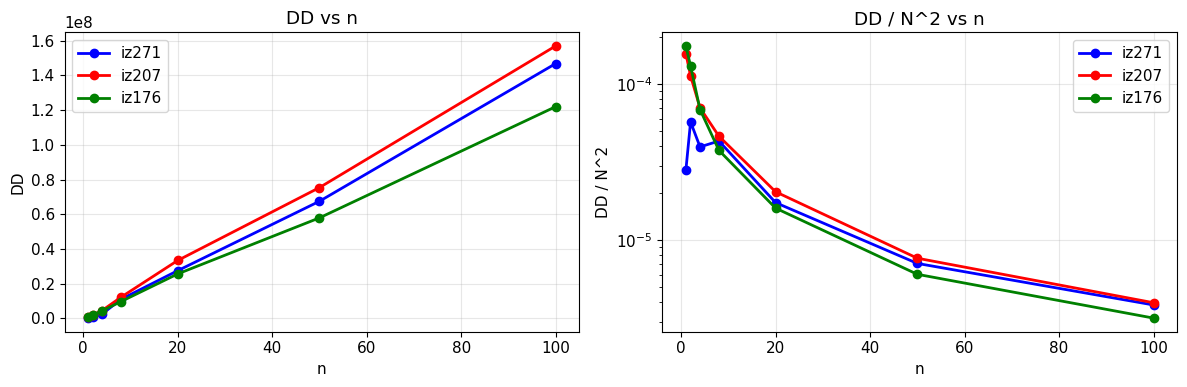

In [9]:
# Extract pair counts (DD) from multiple n values
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

pair_counts_data = []
base_dir_path = Path(get_base_dir())

for iz_num in [271, 207, 176]:
    iz_name = f"iz{iz_num}"
    print(f"\n{iz_name}:")
    mass_cut = 1e10
    boxsize = 542.158
    r_target = 2.0
    for n in [1, 2, 4, 8, 20, 50, 100]:
        
        all_pos = []
        iz_path = str(base_dir_path / iz_name)
        for ivol in range(n):
            try:
                pos, _ = _load_positions_from_hdf5(iz_path, ivol + 100, centrals_only=False, mhalo_min=mass_cut)
                all_pos.append(pos)
            except (FileNotFoundError, KeyError):
                print(f"FileNotFoundError {iz_path}, ivol={ivol}, {KeyError}")
                continue
        
        if not all_pos:
            continue
            
        combined_pos = np.vstack(all_pos)
        ngal = len(combined_pos)
        
        
        rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
        results = corrfunc_xi(
            boxsize=boxsize,
            nthreads=16,
            binfile=rbins_test,
            X=combined_pos[:, 0],
            Y=combined_pos[:, 1],
            Z=combined_pos[:, 2],
            output_ravg=True,
        )
        
        dd = None
        for res in results:
            if res['ravg'] >= r_target:
                dd = int(res['npairs'])
                break
        
        if dd is not None:
            pair_counts_data.append({
                'iz': iz_name,
                'n': n,
                'ngal': ngal,
                'dd_actual': dd,
            })
            
            print(f"  n={n:3d}: N_gal={ngal:10d}, DD(r={r_target})={dd:10d}")

pair_counts_df = pd.DataFrame(pair_counts_data)
print("\n" + "="*70)
print("Pair Counts Summary:")
print(pair_counts_df)


####

# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207', 'iz176']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"{'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"{row['n']:3d} | {row['ngal']:10d} | {row['dd_actual']:10d} | {dd_per_n2:12.4e}")

####

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red'), ('iz176', 'green')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

## Different sub volumes used


iz271:
  n=  1: N_gal=     32224, DD(r=2.0)=       484
  n=  2: N_gal=     64420, DD(r=2.0)=      1870
  n=  4: N_gal=    128798, DD(r=2.0)=      7516
  n=  8: N_gal=    258371, DD(r=2.0)=     30400
  n= 20: N_gal=    645485, DD(r=2.0)=    191376
  n= 50: N_gal=   1615232, DD(r=2.0)=   1204830
  n=100: N_gal=   3233070, DD(r=2.0)=   4820692

iz207:
  n=  1: N_gal=     34727, DD(r=2.0)=     26068
  n=  2: N_gal=     69857, DD(r=2.0)=     58002
  n=  4: N_gal=    140573, DD(r=2.0)=    134026
  n=  8: N_gal=    283579, DD(r=2.0)=    323010
  n= 20: N_gal=    708346, DD(r=2.0)=    942766
  n= 50: N_gal=   1770582, DD(r=2.0)=   3062874
  n=100: N_gal=   3553553, DD(r=2.0)=   8777328

iz176:
  n=  1: N_gal=     36336, DD(r=2.0)=     68792
  n=  2: N_gal=     73534, DD(r=2.0)=    151464
  n=  4: N_gal=    149273, DD(r=2.0)=    332080
  n=  8: N_gal=    302846, DD(r=2.0)=    753854
  n= 20: N_gal=    757111, DD(r=2.0)=   2019434
  n= 50: N_gal=   1891876, DD(r=2.0)=   5727478
  n=100: N_gal= 


iz271:
  n=  1: N_gal=     32224, DD(r=2.0)=       484
  n=  2: N_gal=     64420, DD(r=2.0)=      1870
  n=  4: N_gal=    128798, DD(r=2.0)=      7516
  n=  8: N_gal=    258371, DD(r=2.0)=     30400
  n= 20: N_gal=    645485, DD(r=2.0)=    191376
  n= 50: N_gal=   1615232, DD(r=2.0)=   1204830
  n=100: N_gal=   3233070, DD(r=2.0)=   4820692

iz207:
  n=  1: N_gal=     34727, DD(r=2.0)=     26068
  n=  2: N_gal=     69857, DD(r=2.0)=     58002
  n=  4: N_gal=    140573, DD(r=2.0)=    134026
  n=  8: N_gal=    283579, DD(r=2.0)=    323010
  n= 20: N_gal=    708346, DD(r=2.0)=    942766
  n= 50: N_gal=   1770582, DD(r=2.0)=   3062874
  n=100: N_gal=   3553553, DD(r=2.0)=   8777328

iz176:
  n=  1: N_gal=     36336, DD(r=2.0)=     68792
  n=  2: N_gal=     73534, DD(r=2.0)=    151464
  n=  4: N_gal=    149273, DD(r=2.0)=    332080
  n=  8: N_gal=    302846, DD(r=2.0)=    753854
  n= 20: N_gal=    757111, DD(r=2.0)=   2019434
  n= 50: N_gal=   1891876, DD(r=2.0)=   5727478
  n=100: N_gal= 

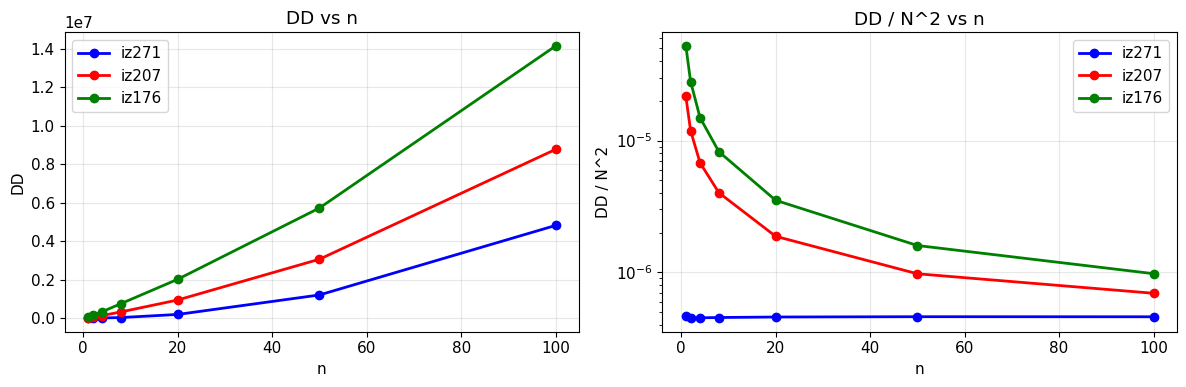

In [12]:
# Extract pair counts (DD) from multiple n values
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

pair_counts_data = []
base_dir_path = Path(get_base_dir())

for iz_num in [271, 207, 176]:
    iz_name = f"iz{iz_num}"
    print(f"\n{iz_name}:")
    mass_cut = 1e10
    boxsize = 542.158
    r_target = 2.0
    for n in [1, 2, 4, 8, 20, 50, 100]:
        
        all_pos = []
        iz_path = str(base_dir_path / iz_name)
        for ivol in range(n):
            try:
                pos, _ = _load_positions_from_hdf5(iz_path, ivol + 600, centrals_only=True, mhalo_min=mass_cut)
                all_pos.append(pos)
            except (FileNotFoundError, KeyError):
                print(f"FileNotFoundError {iz_path}, ivol={ivol}, {KeyError}")
                continue
        
        if not all_pos:
            continue
            
        combined_pos = np.vstack(all_pos)
        ngal = len(combined_pos)
        
        
        rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
        results = corrfunc_xi(
            boxsize=boxsize,
            nthreads=16,
            binfile=rbins_test,
            X=combined_pos[:, 0],
            Y=combined_pos[:, 1],
            Z=combined_pos[:, 2],
            output_ravg=True,
        )
        
        dd = None
        for res in results:
            if res['ravg'] >= r_target:
                dd = int(res['npairs'])
                break
        
        if dd is not None:
            pair_counts_data.append({
                'iz': iz_name,
                'n': n,
                'ngal': ngal,
                'dd_actual': dd,
            })
            
            print(f"  n={n:3d}: N_gal={ngal:10d}, DD(r={r_target})={dd:10d}")

pair_counts_df = pd.DataFrame(pair_counts_data)
print("\n" + "="*70)
print("Pair Counts Summary:")
print(pair_counts_df)


####

# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207', 'iz176']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"{'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"{row['n']:3d} | {row['ngal']:10d} | {row['dd_actual']:10d} | {dd_per_n2:12.4e}")

####

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red'), ('iz176', 'green')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

## Group sub volumes in each n

In [ ]:
# Extract pair counts (DD) for iz271 with subvolumes [1,2,3,4,5] - same as Cell 35 (weighted 2PCF)
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

iz_num = 271
iz_name = f"iz{iz_num}"
ivols = [1, 2, 3, 4, 5]  # SAME AS CELL 35
mass_cut = 1e10
boxsize = 542.158
r_target = 2.0

print(f"Computing raw pair counts (DD) for {iz_name} with subvolumes {ivols}...")
print("Using nthreads=16")
print("")

all_pos = []
base_dir_path = Path(get_base_dir())
iz_path = str(base_dir_path / iz_name)

# Load specified subvolumes
for ivol in ivols:
    try:
        pos, _ = _load_positions_from_hdf5(iz_path, ivol + 600, centrals_only=True, mhalo_min=mass_cut)
        all_pos.append(pos)
        print(f"  ivol={ivol}: Loaded {len(pos)} galaxies")
    except (FileNotFoundError, KeyError) as e:
        print(f"  ivol={ivol}: Error - {e}")
        continue

if not all_pos:
    print("✗ No positions loaded")
else:
    combined_pos = np.vstack(all_pos)
    ngal = len(combined_pos)
    print(f"\nTotal galaxies combined: {ngal}")
    print(f"Sampling fraction: {len(ivols)}/1024 = {len(ivols)/1024:.4f}")
    
    # Compute correlation function
    rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
    print(f"\nComputing correlation function with {len(rbins_test)} radial bins...")
    
    results = corrfunc_xi(
        boxsize=boxsize,
        nthreads=16,
        binfile=rbins_test,
        X=combined_pos[:, 0],
        Y=combined_pos[:, 1],
        Z=combined_pos[:, 2],
        output_ravg=True,
    )
    
    # Extract and display pair counts
    print("\nPair Counts at each radius:")
    print(f"{'r [Mpc/h]':>12} | {'DD (pairs)':>15} | {'DD / N²':>15}")
    print("-" * 50)
    
    pair_data = []
    for res in results:
        r = res['ravg']
        dd = int(res['npairs'])
        dd_per_n2 = dd / (ngal ** 2)
        print(f"{r:12.3f} | {dd:15d} | {dd_per_n2:15.4e}")
        pair_data.append({'r': r, 'dd': dd, 'dd_per_n2': dd_per_n2})
    
    # Plot pair counts vs radius
    fig, ax = plt.subplots(figsize=(10, 6))
    rs = np.array([d['r'] for d in pair_data])
    dds = np.array([d['dd'] for d in pair_data])
    
    ax.loglog(rs, dds, 'o-', markersize=8, linewidth=2, label=f"{iz_name} (n_ivols={len(ivols)})")
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('DD (Pair Count)', fontsize=12)
    ax.set_title(f'Pair Counts vs Radius: {iz_name} - Raw DD Analysis', fontsize=12)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Pair count analysis complete")


####

# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207', 'iz176']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"{'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"{row['n']:3d} | {row['ngal']:10d} | {row['dd_actual']:10d} | {dd_per_n2:12.4e}")

####

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red'), ('iz176', 'green')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

## Pair Counts for Each sub volume, averaged


iz271:


  n=  1: N_gal_mean=   57943.0,  DD_mean(r=2.0)=  136554.0, DD_std=     0.0  (n_used=1, n_failed=0)
  n=  2: N_gal_mean=   62025.0,  DD_mean(r=2.0)=  466372.0, DD_std= 87474.0  (n_used=2, n_failed=0)
  n=  4: N_gal_mean=   62625.8,  DD_mean(r=2.0)=  813520.5, DD_std=485902.9  (n_used=4, n_failed=0)
  n=  8: N_gal_mean=   61850.0,  DD_mean(r=2.0)= 1429557.2, DD_std=1852709.4  (n_used=8, n_failed=0)
  n= 20: N_gal_mean=   62743.9,  DD_mean(r=2.0)= 1338377.1, DD_std=1447092.5  (n_used=20, n_failed=0)
  n= 50: N_gal_mean=   62023.7,  DD_mean(r=2.0)= 1075010.0, DD_std=1525473.4  (n_used=50, n_failed=0)
  n=100: N_gal_mean=   61859.9,  DD_mean(r=2.0)= 1084077.5, DD_std=1392136.4  (n_used=100, n_failed=0)

iz207:
  n=  1: N_gal_mean=   71106.0,  DD_mean(r=2.0)= 2236678.0, DD_std=     0.0  (n_used=1, n_failed=0)
  n=  2: N_gal_mean=   67052.0,  DD_mean(r=2.0)= 1971841.0, DD_std=  1189.0  (n_used=2, n_failed=0)
  n=  4: N_gal_mean=   63888.2,  DD_mean(r=2.0)= 1192265.0, DD_std=347259.8  (n_used

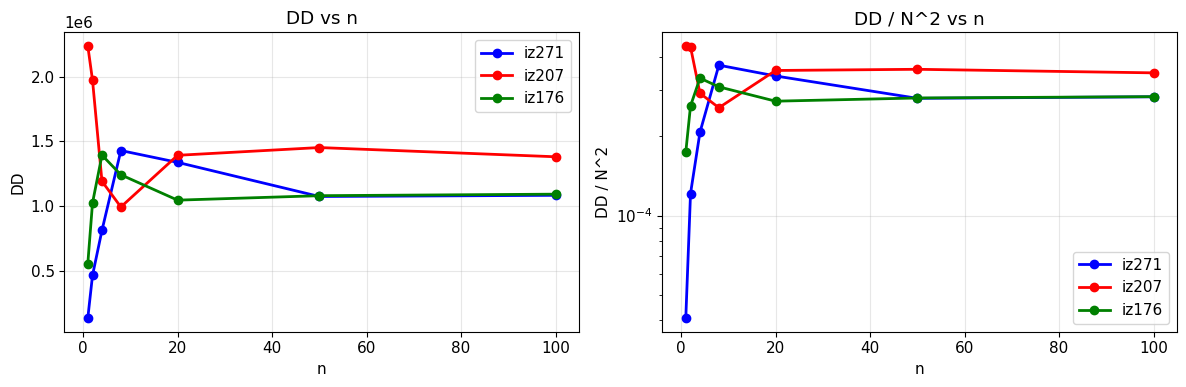

In [11]:
# Extract pair counts (DD) from multiple n values
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

pair_counts_data = []
base_dir_path = Path(get_base_dir())
rng = np.random.default_rng(42)
ivol_pool = np.arange(0, 101)

for iz_num in [271, 207, 176]:
    iz_name = f"iz{iz_num}"
    print(f"\n{iz_name}:")
    mass_cut = 1e10
    boxsize = 542.158
    r_target = 2.0
    rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
    for n in [1, 2, 4, 8, 20, 50, 100]:
        dd_list = []
        ngal_list = []
        failures = []
        iz_path = str(base_dir_path / iz_name)
        ivol_sample = rng.choice(ivol_pool, size=n, replace=False) if n > 0 else []
        for ivol in ivol_sample:
            try:
                pos, _ = _load_positions_from_hdf5(
                    iz_path, int(ivol) + 100, centrals_only=False, mhalo_min=mass_cut
                )
            except (FileNotFoundError, KeyError) as exc:
                failures.append((int(ivol), exc))
                print(f"Error loading {iz_path}, ivol={ivol}: {exc}")
                continue
            if pos.size == 0:
                failures.append((int(ivol), ValueError("empty positions")))
                print(f"Error loading {iz_path}, ivol={ivol}: empty positions")
                continue
            results = corrfunc_xi(
                boxsize=boxsize,
                nthreads=16,
                binfile=rbins_test,
                X=pos[:, 0],
                Y=pos[:, 1],
                Z=pos[:, 2],
                output_ravg=True,
            )
            dd = None
            for res in results:
                if res['ravg'] >= r_target:
                    dd = int(res['npairs'])
                    break
            if dd is not None:
                dd_list.append(dd)
                ngal_list.append(len(pos))
        if not dd_list:
            continue
        dd_mean = float(np.mean(dd_list))
        dd_std = float(np.std(dd_list))
        ngal_mean = float(np.mean(ngal_list))
        pair_counts_data.append({
            'iz': iz_name,
            'n': n,
            'ngal': ngal_mean,
            'dd_actual': dd_mean,
            'dd_std': dd_std,
            'n_used': len(dd_list),
            'n_failed': len(failures),
        })
        print(
            f"  n={n:3d}: N_gal_mean={ngal_mean:10.1f}, ",
            f"DD_mean(r={r_target})={dd_mean:10.1f}, DD_std={dd_std:8.1f} ",
            f"(n_used={len(dd_list)}, n_failed={len(failures)})",
        )

pair_counts_df = pd.DataFrame(pair_counts_data)
print("\n" + "="*70)
print("Pair Counts Summary:")
print(pair_counts_df)


####

# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207', 'iz176']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"{'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"{row['n']:3d} | {row['ngal']:10.1f} | {row['dd_actual']:10.1f} | {dd_per_n2:12.4e}")

####

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red'), ('iz176', 'green')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

In [5]:
from galform_analysis.config import get_base_dir
base_dir = get_base_dir()
available_ivols = completed_galaxies(str(base_dir), [str(271)])


## Weighted Correlation Function

In [5]:
import pandas as pd
from pathlib import Path

results_root = Path("/cosma/home/durham/dc-hick2/galform_analysis/convergence_results_weighted")

CONFIGS = {
    "mhalo1e9_cen":  dict(label="mhalo>1e9 (centrals)", color_offset=0.0),
    "mhalo1e9_all":  dict(label="mhalo>1e9 (all)",      color_offset=0.25),
    "mhalo1e10_cen": dict(label="mhalo>1e10 (centrals)", color_offset=0.5),
    "mhalo1e10_all": dict(label="mhalo>1e10 (all)",      color_offset=0.75),
}

IZ_NUMS = [271, 207, 176]

# ── load all CSVs ────────────────────────────────────────────────────────────
dfs = {}
for tag in CONFIGS:
    frames = []
    for iz in IZ_NUMS:
        csv_path = results_root / tag / f"corr_convergence_iz{iz}.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["tag"] = tag
            frames.append(df)
        else:
            print(f"Not yet available: {csv_path.relative_to(results_root.parent)}")
    if frames:
        dfs[tag] = pd.concat(frames, ignore_index=True)

if not dfs:
    print("No results available yet – SLURM jobs still running.")
else:
    # ── one figure per mass/galaxy config, rows = redshifts ─────────────────
    for tag, cfg in CONFIGS.items():
        if tag not in dfs:
            continue
        data = dfs[tag]
        available_iz = sorted(data["iz"].unique())

        fig, axes = plt.subplots(
            1, len(available_iz),
            figsize=(6 * len(available_iz), 5),
            sharey=True,
        )
        if len(available_iz) == 1:
            axes = [axes]

        n_vals = sorted(data["n_ivols"].unique())
        cmap = plt.cm.viridis(np.linspace(0, 1, len(n_vals)))
        color_of = {n: c for n, c in zip(n_vals, cmap)}

        for ax, iz_str in zip(axes, available_iz):
            sub = data[data["iz"] == iz_str]
            for n in n_vals:
                row = sub[sub["n_ivols"] == n].sort_values("r")
                if row.empty:
                    continue
                ax.loglog(
                    row["r"], row["xi"],
                    "o-", lw=1.5, ms=4,
                    color=color_of[n],
                    label=f"n={n}",
                )
            ax.set_xlabel("r [Mpc/h]", fontsize=11)
            ax.set_title(iz_str, fontsize=11)
            ax.grid(True, alpha=0.3, which="both")
            ax.legend(fontsize=8, loc="best", ncol=2)

        axes[0].set_ylabel(r"$\xi(r)$", fontsize=12)
        fig.suptitle(f"Weighted 2PCF convergence – {cfg['label']}", fontsize=13)
        plt.tight_layout()
        plt.show()
        print(f"  {tag}: {len(n_vals)} n-values, "
              f"{len(available_iz)} redshifts, "
              f"{len(data)} total rows")


Not yet available: convergence_results_weighted/mhalo1e9_cen/corr_convergence_iz271.csv
Not yet available: convergence_results_weighted/mhalo1e9_cen/corr_convergence_iz207.csv
Not yet available: convergence_results_weighted/mhalo1e9_cen/corr_convergence_iz176.csv
Not yet available: convergence_results_weighted/mhalo1e9_all/corr_convergence_iz271.csv
Not yet available: convergence_results_weighted/mhalo1e9_all/corr_convergence_iz207.csv
Not yet available: convergence_results_weighted/mhalo1e9_all/corr_convergence_iz176.csv
Not yet available: convergence_results_weighted/mhalo1e10_cen/corr_convergence_iz271.csv
Not yet available: convergence_results_weighted/mhalo1e10_cen/corr_convergence_iz207.csv
Not yet available: convergence_results_weighted/mhalo1e10_cen/corr_convergence_iz176.csv
Not yet available: convergence_results_weighted/mhalo1e10_all/corr_convergence_iz271.csv
Not yet available: convergence_results_weighted/mhalo1e10_all/corr_convergence_iz207.csv
Not yet available: converge

In [ ]:
from galform_analysis.analysis.correlation.mass_weighted_correlation import (
    avg_weighted_correlation_given_redshift_and_subvolumes,
)

IZ_LIST = [271, 207, 176]
N_STEPS = np.linspace(1,10)
RBINS = np.logspace(np.log10(0.1), np.log10(50.0), 20)
RMIDS= (RBINS[:-1] + RBINS[1:]) / 2
BOXSIZE = 542.158
MHALO_MIN = 1e9
MSTAR_MIN = 9.0
N_TOTAL = 1024
V_SUBVOL_RELATIVE = BOXSIZE**3 / N_TOTAL   

CONFIGS = [
    dict(centrals_only=True, label="Centrals only"),
    dict(centrals_only=False, label="Centrals + satellites"),
]

records_wcf = {}

for cfg_idx, cfg in enumerate(CONFIGS):
    for iz in IZ_LIST:
        for N in N_STEPS:
            wc = avg_weighted_correlation_given_redshift_and_subvolumes(
                iz_num=iz,
                ivols=list(range(1, N + 1)),
                rbins=RBINS,
                nthreads=16,
                base_dir=str(base_dir),
                centrals_only=cfg["centrals_only"],
                mhalo_min=MHALO_MIN,
                mstar_min_log10=MSTAR_MIN,
                boxsize=BOXSIZE,
            )
            
            n_loaded = wc.attrs.get("n_ivols", N)
            ngal = wc.attrs.get("total_galaxies", 0)
            nbar = ngal / (n_loaded * V_SUBVOL_RELATIVE)
            xi = wc["xi"].values

            records_wcf[(iz, cfg_idx, N)] = {"nbar": nbar, "xi": xi}
            n_pos = int(np.sum(xi > 0))

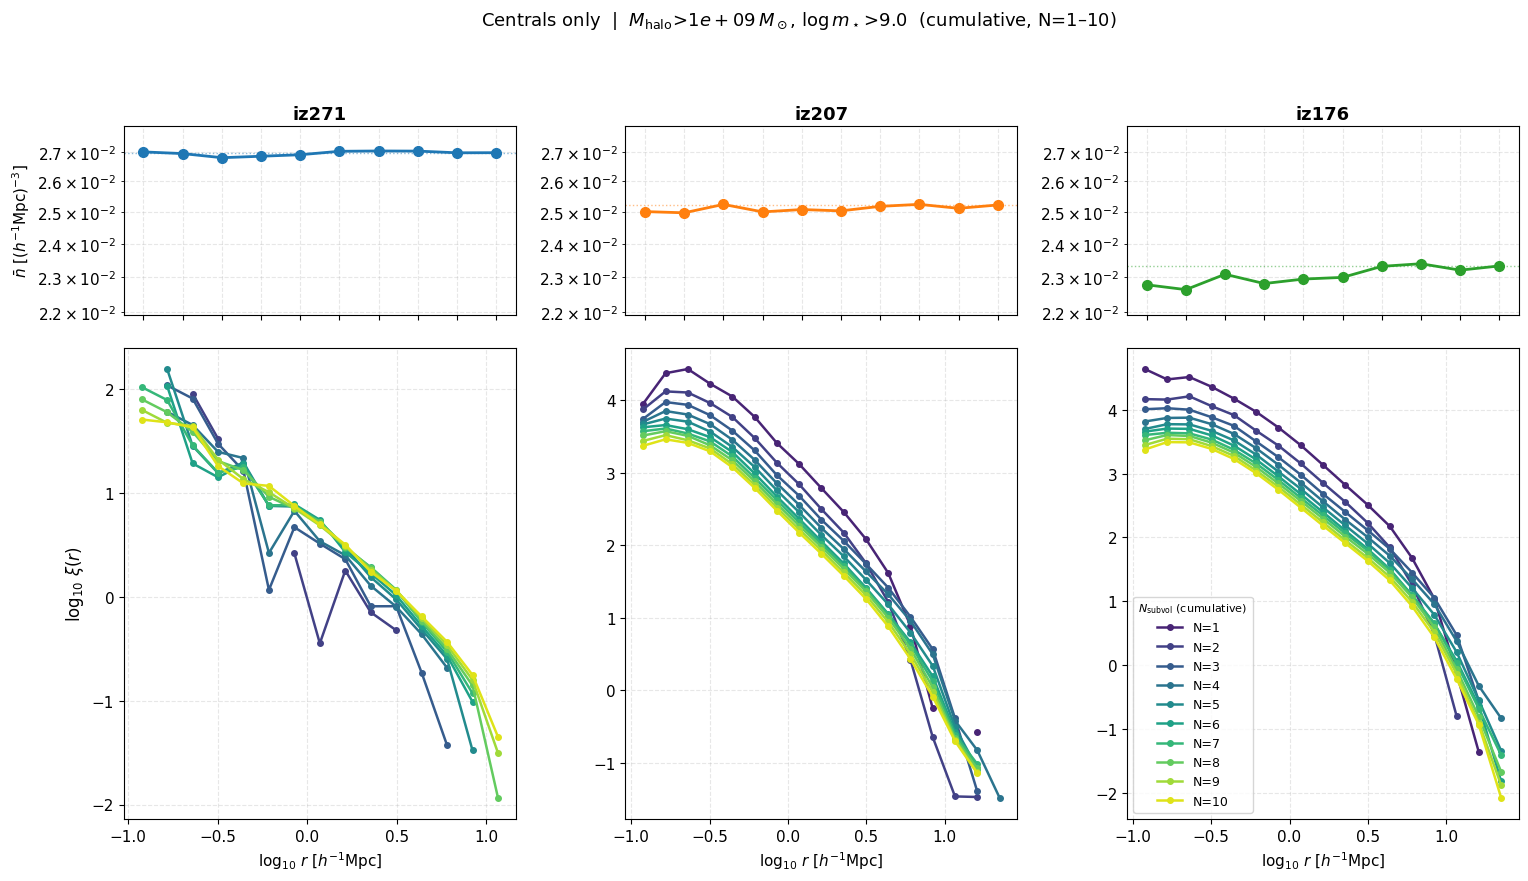

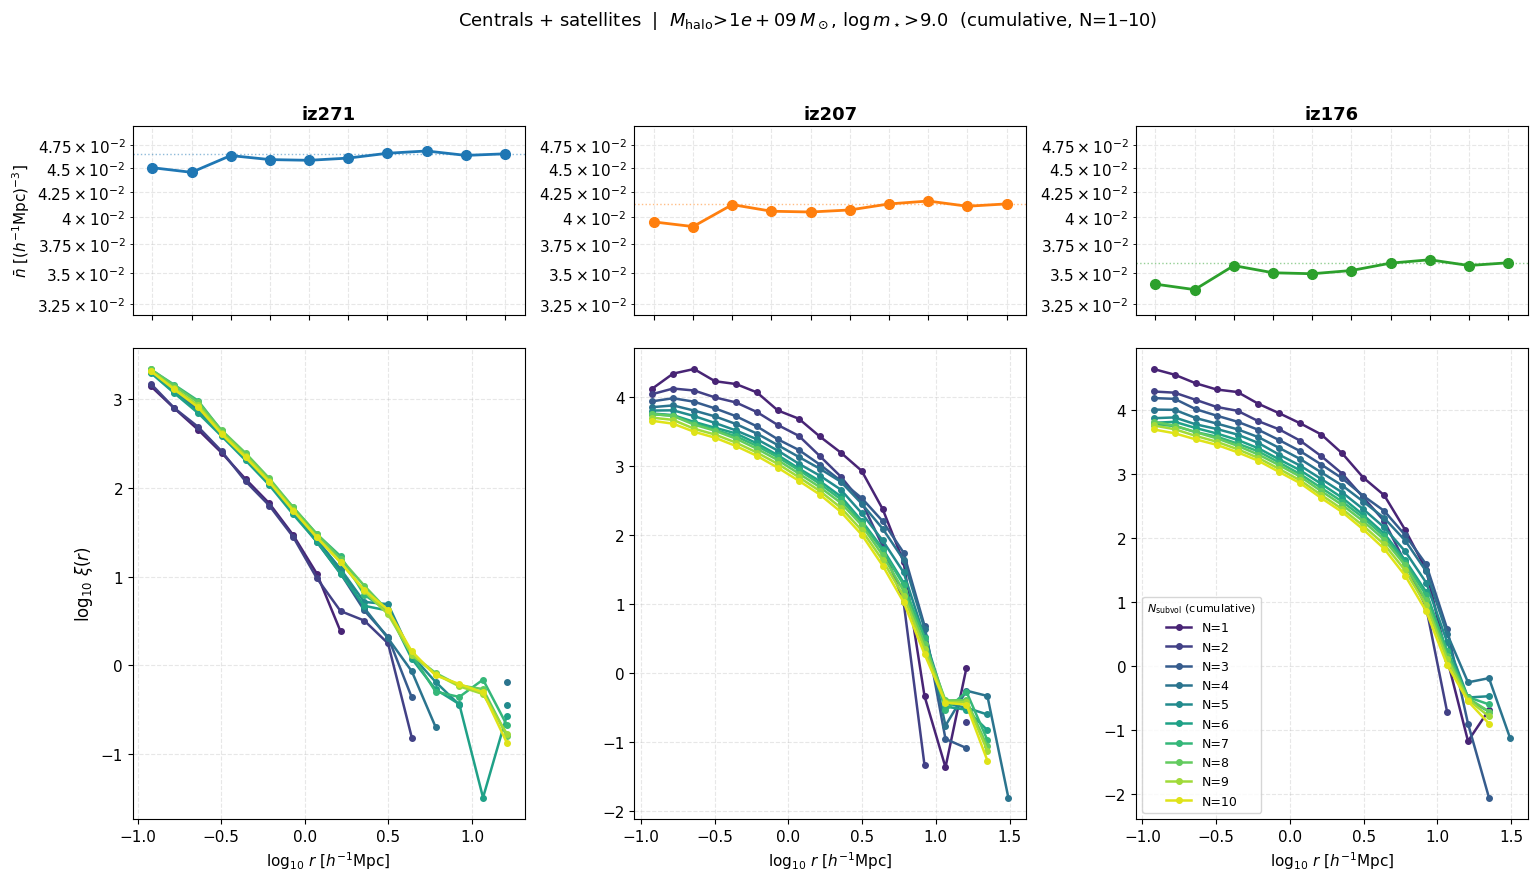

In [ ]:
import matplotlib.ticker as ticker

cmap_n   = plt.cm.viridis(np.linspace(0.1, 0.95, len(N_STEPS)))
col_of_n = {n: c for n, c in zip(N_STEPS, cmap_n)}

for cfg_idx, cfg in enumerate(CONFIGS):
    fig = plt.figure(figsize=(6 * len(IZ_LIST), 9))
    gs  = fig.add_gridspec(
        2, len(IZ_LIST),
        height_ratios=[1, 2.5],
        hspace=0.10, wspace=0.28,
    )

    all_nb = [
        records_wcf[(iz, cfg_idx, n)]["nbar"]
        for iz in IZ_LIST for n in N_STEPS
        if np.isfinite(records_wcf[(iz, cfg_idx, n)]["nbar"])
    ]
    nb_lo = min(all_nb)
    nb_hi = max(all_nb)
    if nb_lo < nb_hi:
        pad = (nb_hi / nb_lo) ** 0.18
    else:
        pad = 1.2

    IZ_COLORS_LOC = {271: "tab:blue", 207: "tab:orange", 176: "tab:green"}

    for col, iz in enumerate(IZ_LIST):
        ax_nb = fig.add_subplot(gs[0, col])
        ax_xi = fig.add_subplot(gs[1, col])

        nb_vals = [records_wcf[(iz, cfg_idx, n)]["nbar"] for n in N_STEPS]
        ax_nb.plot(N_STEPS, nb_vals, "o-", lw=2, ms=7,
                   color=IZ_COLORS_LOC[iz], zorder=3)
        ax_nb.axhline(nb_vals[-1], ls=":", lw=1,
                      color=IZ_COLORS_LOC[iz], alpha=0.5)
        ax_nb.set_yscale("log")
        ax_nb.set_ylim(nb_lo / pad, nb_hi * pad)
        ax_nb.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
        ax_nb.set_xticks(N_STEPS)
        ax_nb.set_xlim(0.5, max(N_STEPS) + 0.5)
        ax_nb.tick_params(labelbottom=False)
        ax_nb.grid(True, which="both", ls="--", alpha=0.3)
        ax_nb.set_title(f"iz{iz}", fontsize=13, fontweight="bold", pad=5)
        if col == 0:
            ax_nb.set_ylabel(
                r"$\bar{n}\ [(h^{-1}\mathrm{Mpc})^{-3}]$", fontsize=11)

        for n in N_STEPS:
            xi  = records_wcf[(iz, cfg_idx, n)]["xi"]
            pos = np.where(xi > 0, xi, np.nan)
            ax_xi.plot(
                np.log10(RMIDS), np.log10(pos),
                "o-", lw=1.8, ms=4,
                color=col_of_n[n],
                label=f"N={n}",
                zorder=3,
            )
        ax_xi.set_xlabel(
            r"$\log_{10}\,r\ [h^{-1}\mathrm{Mpc}]$", fontsize=11)
        ax_xi.grid(True, ls="--", alpha=0.3)
        if col == 0:
            ax_xi.set_ylabel(r"$\log_{10}\,\xi(r)$", fontsize=12)
        if col == len(IZ_LIST) - 1:
            ax_xi.legend(
                fontsize=9, loc="lower left",
                title=r"$N_\mathrm{subvol}$ (cumulative)",
                title_fontsize=8,
            )

        ax_nb.sharex(ax_xi) if False else None 

    fig.suptitle(
        rf"{cfg['label']}  |  "
        rf"$M_\mathrm{{halo}}\!>\!{MHALO_MIN:.0e}\,M_\odot$, "
        rf"$\log m_\star\!>\!{MSTAR_MIN}$  "
        rf"(cumulative, N=1 -{max(N_STEPS)})",
        fontsize=13, y=1.01,
    )
    plt.show()


In [ ]:
import matplotlib.ticker as ticker
from galform_analysis.analysis.correlation.mass_weighted_correlation import (
    avg_weighted_correlation_given_redshift_and_subvolumes,
)

IZ_LIST   = [271, 207, 176]
N_STEPS   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
RBINS     = np.logspace(np.log10(0.1), np.log10(50.0), 20)
RMIDS     = (RBINS[:-1] + RBINS[1:]) / 2
BOXSIZE   = 542.158
MHALO_MIN = 1e9
MSTAR_MIN = 9.0
N_TOTAL   = 1024
V_SUBVOL_RELATIVE = BOXSIZE**3 / N_TOTAL

CONFIGS = [
    dict(centrals_only=True,  label="Centrals only"),
    dict(centrals_only=False, label="Centrals + satellites"),
]

records_wcf = {}  
records_cf  = {}  

for cfg_idx, cfg in enumerate(CONFIGS):
    for iz in IZ_LIST:
        for N in N_STEPS:
            ivols = list(range(1, N + 1))

            # weighted
            wc = avg_weighted_correlation_given_redshift_and_subvolumes(
                iz_num=iz, ivols=ivols, rbins=RBINS, nthreads=16,
                base_dir=str(base_dir), centrals_only=cfg["centrals_only"],
                mhalo_min=MHALO_MIN, mstar_min_log10=MSTAR_MIN, boxsize=BOXSIZE,
            )
            n_loaded = wc.attrs.get("n_ivols", N)
            ngal     = wc.attrs.get("total_galaxies", 0)
            nbar     = ngal / (n_loaded * V_SUBVOL_RELATIVE)
            records_wcf[(iz, cfg_idx, N)] = {"nbar": nbar, "xi": wc["xi"].values}

            # unweighted
            uc = avg_correlation_given_redshift_and_subvolumes(
                iz_num=iz, ivols=ivols, rbins=RBINS, nthreads=16,
                base_dir=str(base_dir), centrals_only=cfg["centrals_only"],
                mhalo_min=MHALO_MIN,
            )
            if uc is not None:
                xi_u = uc["xi"].values
            else:
                xi_u = np.full(len(RMIDS), np.nan)
            records_cf[(iz, cfg_idx, N)] = {"nbar": nbar, "xi": xi_u}

            n_pos_w = int(np.sum(wc["xi"].values > 0))
            n_pos_u = int(np.sum(xi_u > 0))

cmap_n   = plt.cm.viridis(np.linspace(0.1, 0.95, len(N_STEPS)))
col_of_n = {n: c for n, c in zip(N_STEPS, cmap_n)}
IZ_COLORS_LOC = {271: "tab:blue", 207: "tab:orange", 176: "tab:green"}

for cfg_idx, cfg in enumerate(CONFIGS):
    fig = plt.figure(figsize=(6 * len(IZ_LIST), 13))
    gs  = fig.add_gridspec(
        3, len(IZ_LIST),
        height_ratios=[1, 2.5, 2.5],
        hspace=0.12, wspace=0.28,
    )

    all_nb = [
        records_wcf[(iz, cfg_idx, n)]["nbar"]
        for iz in IZ_LIST for n in N_STEPS
        if np.isfinite(records_wcf[(iz, cfg_idx, n)]["nbar"])
    ]
    nb_lo, nb_hi = min(all_nb), max(all_nb)
    pad = (nb_hi / nb_lo) ** 0.18 if nb_lo < nb_hi else 1.2

    def _finite_xi_range(records):
        vals = []
        for iz in IZ_LIST:
            for n in N_STEPS:
                xi = records[(iz, cfg_idx, n)]["xi"]
                pos = xi[xi > 0]
                if len(pos): vals.extend(np.log10(pos).tolist())
        return (min(vals) if vals else -2), (max(vals) if vals else 6)

    xi_lo_w, xi_hi_w = _finite_xi_range(records_wcf)
    xi_lo_u, xi_hi_u = _finite_xi_range(records_cf)
    xi_lo = min(xi_lo_w, xi_lo_u) - 0.3
    xi_hi = max(xi_hi_w, xi_hi_u) + 0.3

    for col, iz in enumerate(IZ_LIST):
        ax_nb  = fig.add_subplot(gs[0, col])
        ax_w   = fig.add_subplot(gs[1, col])
        ax_u   = fig.add_subplot(gs[2, col])

        nb_vals = [records_wcf[(iz, cfg_idx, n)]["nbar"] for n in N_STEPS]
        ax_nb.plot(N_STEPS, nb_vals, "o-", lw=2, ms=7,
                   color=IZ_COLORS_LOC[iz], zorder=3)
        ax_nb.axhline(nb_vals[-1], ls=":", lw=1,
                      color=IZ_COLORS_LOC[iz], alpha=0.5)
        ax_nb.set_yscale("log")
        ax_nb.set_ylim(nb_lo / pad, nb_hi * pad)
        ax_nb.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
        ax_nb.set_xticks(N_STEPS)
        ax_nb.set_xlim(0.5, max(N_STEPS) + 0.5)
        ax_nb.tick_params(labelbottom=False)
        ax_nb.grid(True, which="both", ls="--", alpha=0.3)
        ax_nb.set_title(f"iz{iz}", fontsize=13, fontweight="bold", pad=5)
        if col == 0:
            ax_nb.set_ylabel(r"$\bar{n}\ [(h^{-1}\mathrm{Mpc})^{-3}]$", fontsize=11)

        for n in N_STEPS:
            xi  = records_wcf[(iz, cfg_idx, n)]["xi"]
            pos = np.where(xi > 0, xi, np.nan)
            ax_w.plot(np.log10(RMIDS), np.log10(pos), "o-",
                      lw=1.8, ms=4, color=col_of_n[n], label=f"N={n}", zorder=3)
        ax_w.set_ylim(xi_lo, xi_hi)
        ax_w.grid(True, ls="--", alpha=0.3)
        ax_w.tick_params(labelbottom=False)
        if col == 0:
            ax_w.set_ylabel(r"$\log_{10}\,\xi_\mathrm{w}(r)$", fontsize=12)
        if col == len(IZ_LIST) - 1:
            ax_w.legend(fontsize=8, loc="lower left",
                        title=r"$N_\mathrm{subvol}$", title_fontsize=8)

        for n in N_STEPS:
            xi  = records_cf[(iz, cfg_idx, n)]["xi"]
            pos = np.where(xi > 0, xi, np.nan)
            ax_u.plot(np.log10(RMIDS), np.log10(pos), "o-",
                      lw=1.8, ms=4, color=col_of_n[n], label=f"N={n}", zorder=3)
        ax_u.set_ylim(xi_lo, xi_hi)
        ax_u.grid(True, ls="--", alpha=0.3)
        ax_u.set_xlabel(r"$\log_{10}\,r\ [h^{-1}\mathrm{Mpc}]$", fontsize=11)
        if col == 0:
            ax_u.set_ylabel(r"$\log_{10}\,\xi_\mathrm{unw}(r)$", fontsize=12)
        if col == len(IZ_LIST) - 1:
            ax_u.legend(fontsize=8, loc="lower left",
                        title=r"$N_\mathrm{subvol}$", title_fontsize=8)

    fig.suptitle(
        rf"{cfg['label']}  |  "
        rf"$M_\mathrm{{halo}}\!>\!{MHALO_MIN:.0e}\,M_\odot$, "
        rf"$\log m_\star\!>\!{MSTAR_MIN}$  (cumulative, N=1{max(N_STEPS)})"
        "\n[row 1: weighted  |  row 2: unweighted]",
        fontsize=12, y=1.01,
    )
    plt.show()


## new method

In [7]:
import numpy as np
import pandas as pd

from galform_analysis.analysis.correlation.correlation import notebook_style_correlation_for_nvolumes
from galform_analysis.analysis.correlation.group_sampling_correlation import (
    compute_notebook_style_correlations_for_nvolumes,
)

# Same path style as the notebook examples
BASE_DIR = str(base_dir)
IZ_NUM = 271
N_SUBVOLS = [1, 2, 4, 8, 20, 50]
RBINS = np.logspace(-1, 1.5, 21)
RMIDS = 0.5 * (RBINS[:-1] + RBINS[1:])
LBOX = 542.16

normal_results = notebook_style_correlation_for_nvolumes(
    base_dir=BASE_DIR,
    iz_num=IZ_NUM,
    nvolumes_list=N_SUBVOLS,
    rbins=RBINS,
    boxsize=LBOX,
    mstar_min_log10=9.0,
    mhalo_min=1e11,
    nthreads=4,
)

corrected_results = compute_notebook_style_correlations_for_nvolumes(
    base_dir=BASE_DIR,
    iz_num=IZ_NUM,
    nvolumes_list=N_SUBVOLS,
    rbins=RBINS,
    boxsize=LBOX,
    mstar_min_log10=9.0,
    mhalo_min=1e11,
    n_total_subvolumes=1024,
    num_threads=4,
)

rows = []
for n in N_SUBVOLS:
    df_n = pd.DataFrame(
        {
            'n_subvol': n,
            'r': normal_results[n]['r'],
            'xi_normal': normal_results[n]['xi'],
            'xi_corrected': corrected_results[n]['xi_corrected'],
            'xi_standard_group_module': corrected_results[n]['xi_standard'],
        }
    )
    rows.append(df_n)

corr_2pcf_df = pd.concat(rows, ignore_index=True)

corr_2pcf_summary_df = pd.DataFrame(
    {
        'n_subvol': N_SUBVOLS,
        'ngal': [corrected_results[n]['ngal'] for n in N_SUBVOLS],
    }
)

print('Built DataFrames: corr_2pcf_df and corr_2pcf_summary_df')
display(corr_2pcf_summary_df)
display(corr_2pcf_df.head(12))

Built DataFrames: corr_2pcf_df and corr_2pcf_summary_df


,n_subvol,ngal
0,1,6360
1,2,12728
2,4,26003
3,8,52576
4,20,128288
5,50,318646


,n_subvol,r,xi_normal,xi_corrected,xi_standard_group_module
0,1,0.116676,2.827038e+06,2759.779935,2.827038e+06
1,1,0.155590,1.855037e+06,1810.560148,1.855037e+06
2,1,0.207483,1.114486e+06,1087.365975,1.114486e+06
3,1,0.276683,6.417532e+05,625.713116,6.417532e+05
4,1,0.368962,3.785451e+05,368.673887,3.785451e+05
5,1,0.492019,2.054146e+05,199.601213,2.054146e+05
6,1,0.656118,1.111048e+05,107.501792,1.111048e+05
7,1,0.874947,5.562467e+04,53.321944,5.562467e+04
8,1,1.166761,2.320102e+04,25.769251,2.320102e+04
9,1,1.555900,6.903766e+03,13.255233,6.903766e+03


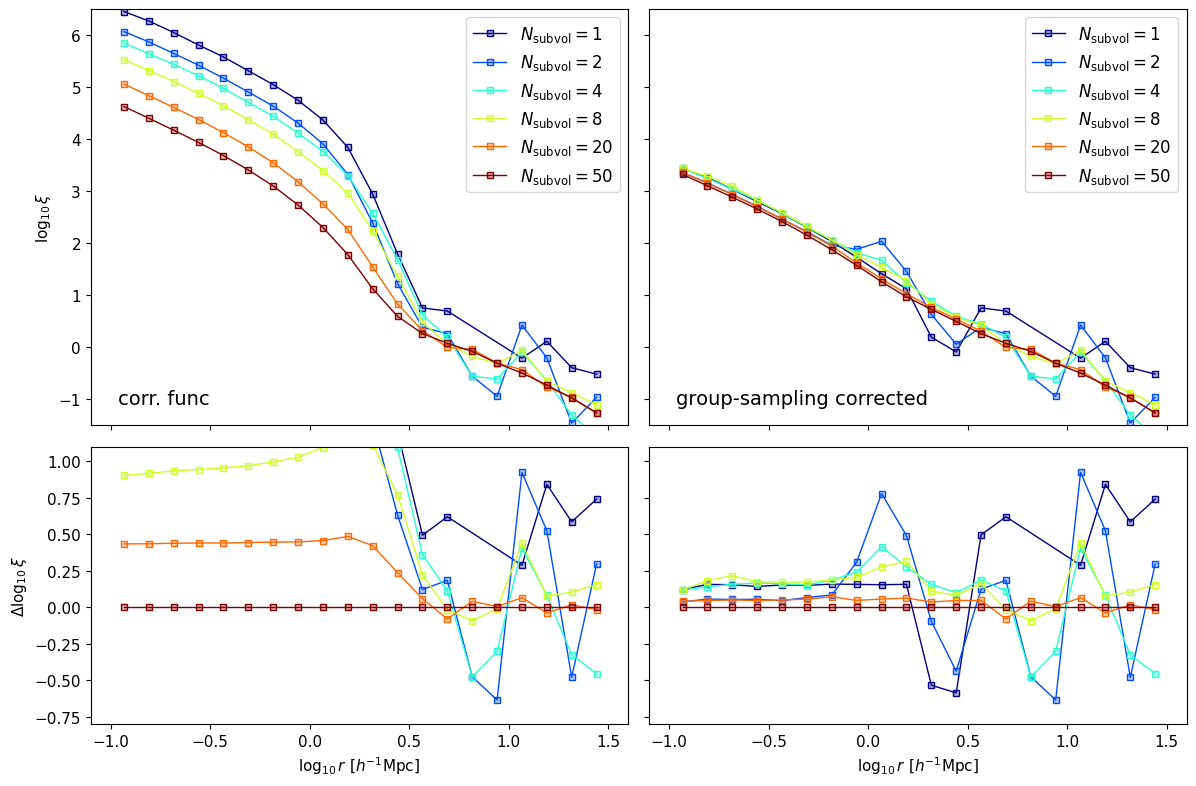

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import matplotlib

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    squeeze=False,
    gridspec_kw={'height_ratios': [3, 2]},
)

eb_kw = dict(ls='-', lw=1, capthick=1, capsize=0, marker='s', ms=8, mew=1)
cmap = matplotlib.colormaps['jet']
colors = cmap(np.linspace(0, 1, len(N_SUBVOLS)))

n_ref = max(N_SUBVOLS)
ref = corr_2pcf_df[corr_2pcf_df['n_subvol'] == n_ref].copy()
ref = ref.set_index('r')

for i, n in enumerate(N_SUBVOLS):
    sub = corr_2pcf_df[corr_2pcf_df['n_subvol'] == n].copy().set_index('r')

    # Top-left: normal xi
    valid_n = sub['xi_normal'] > 0
    x_n = np.log10(sub.index.values[valid_n.values])
    y_n = np.log10(sub.loc[valid_n, 'xi_normal'].values)
    axes[0, 0].plot(
        x_n,
        y_n,
        color=colors[i],
        marker='s',
        ms=4,
        mfc=to_rgba(colors[i], 0.3),
        mec=colors[i],
        lw=1,
        label=rf'$N_{{\rm subvol}}={n}$',
    )

    # Top-right: corrected xi
    valid_c = sub['xi_corrected'] > 0
    x_c = np.log10(sub.index.values[valid_c.values])
    y_c = np.log10(sub.loc[valid_c, 'xi_corrected'].values)
    axes[0, 1].plot(
        x_c,
        y_c,
        color=colors[i],
        marker='s',
        ms=4,
        mfc=to_rgba(colors[i], 0.3),
        mec=colors[i],
        lw=1,
        label=rf'$N_{{\rm subvol}}={n}$',
    )

    # Ratios to largest sample
    ratio_n = sub['xi_normal'] / ref['xi_normal']
    ratio_c = sub['xi_corrected'] / ref['xi_corrected']

    valid_rn = ratio_n > 0
    axes[1, 0].plot(
        np.log10(sub.index.values[valid_rn.values]),
        np.log10(ratio_n[valid_rn].values),
        color=colors[i],
        marker='s',
        ms=4,
        mfc=to_rgba(colors[i], 0.3),
        mec=colors[i],
        lw=1,
    )

    valid_rc = ratio_c > 0
    axes[1, 1].plot(
        np.log10(sub.index.values[valid_rc.values]),
        np.log10(ratio_c[valid_rc].values),
        color=colors[i],
        marker='s',
        ms=4,
        mfc=to_rgba(colors[i], 0.3),
        mec=colors[i],
        lw=1,
    )

axes[0, 0].legend(loc='upper right', fontsize=12)
axes[0, 1].legend(loc='upper right', fontsize=12)
axes[0, 0].annotate('corr. func', (0.05, 0.05), xycoords='axes fraction', fontsize=14)
axes[0, 1].annotate('group-sampling corrected', (0.05, 0.05), xycoords='axes fraction', fontsize=14)

for ax in axes[0, :]:
    ax.set_ylim(-1.5, 6.5)
    ax.set_ylabel(r'$\log_{10}\xi$')
for ax in axes[1, :]:
    ax.set_ylim(-0.8, 1.1)
    ax.set_ylabel(r'$\Delta\log_{10}\xi$')
for ax in fig.get_axes():
    ax.set_xlim(-1.1, 1.6)
    ax.set_xlabel(r'$\log_{10}r~[h^{-1}{\rm Mpc}]$')
    ax.label_outer()

fig.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import to_rgba

from galform_analysis.analysis.correlation.group_sampling_correlation import (
    compute_notebook_style_correlations_for_nvolumes,
 )

# Root containing simulation folders: L800, Mill1, Mill2
base_root = Path('/cosma5/data/durham/dc-hick2/Galform_Out')

# IMPORTANT: use per-simulation box sizes (Mpc/h).
sim_boxsize = {
    'L800': 542.16,
    'Mill1': 365.0,
    'Mill2': 73.0,
}

# Multiple redshifts; Mill2 has only one configured snapshot in this setup
sim_redshifts = {
    'L800': [271, 207, 176],
    'Mill1': [33, 63],
    'Mill2': [40, 67],
}

# Full set for Mill1 and Mill2, and a short set for L800 for speed/consistency with earlier test
sim_nsubvol = {
    'L800': [1, 2, 4],
    'Mill1': [1, 2, 4, 8, 16, 32, 64],
    'Mill2': [1, 2, 4, 8, 10],
}

RBINS_MULTI = np.logspace(-1, 1.5, 21)

all_rows = []
combo_results = {}

for sim, iz_list in sim_redshifts.items():
    sim_base = base_root / sim / 'gp14'
    nvols = sim_nsubvol[sim]
    boxsize = sim_boxsize[sim]

    if not sim_base.exists():
        print(f'Skipping {sim}: missing path {sim_base}')
        continue

    for iz in iz_list:
        print(f'Running {sim} iz{iz} with N_subvol={nvols} boxsize={boxsize}')
        res = compute_notebook_style_correlations_for_nvolumes(
            base_dir=str(sim_base),
            iz_num=iz,
            nvolumes_list=nvols,
            rbins=RBINS_MULTI,
            boxsize=boxsize,
            mstar_min_log10=9.0,
            mhalo_min=1e11,
            n_total_subvolumes=1024,
            num_threads=4,
        )
        combo_results[(sim, iz)] = res

        rvals = 0.5 * (RBINS_MULTI[:-1] + RBINS_MULTI[1:])
        for n in nvols:
            df_tmp = pd.DataFrame(
                {
                    'sim': sim,
                    'iz': iz,
                    'n_subvol': n,
                    'r': rvals,
                    'xi_normal': res[n]['xi_standard'],
                    'xi_corrected': res[n]['xi_corrected'],
                    'ngal': res[n]['ngal'],
                    'boxsize': boxsize,
                }
            )
            all_rows.append(df_tmp)

multi_sim_corr_df = pd.concat(all_rows, ignore_index=True)
display(multi_sim_corr_df.head(12))

# Plot one 2x2 panel per (sim, iz), same style as earlier cell
for (sim, iz), res in combo_results.items():
    nvols = sim_nsubvol[sim]
    rmids = 0.5 * (RBINS_MULTI[:-1] + RBINS_MULTI[1:])

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False, gridspec_kw={'height_ratios': [3, 2]})
    cmap = matplotlib.colormaps['jet']
    colors = cmap(np.linspace(0, 1, len(nvols)))

    n_ref = max(nvols)
    xi_ref_n = np.asarray(res[n_ref]['xi_standard'])
    xi_ref_c = np.asarray(res[n_ref]['xi_corrected'])

    for i, n in enumerate(nvols):
        xi_n = np.asarray(res[n]['xi_standard'])
        xi_c = np.asarray(res[n]['xi_corrected'])

        valid_n = xi_n > 0
        axes[0, 0].plot(
            np.log10(rmids[valid_n]),
            np.log10(xi_n[valid_n]),
            color=colors[i],
            marker='s',
            ms=4,
            mfc=to_rgba(colors[i], 0.3),
            mec=colors[i],
            lw=1,
            label=rf'$N_{{\\rm subvol}}={n}$',
        )

        valid_c = xi_c > 0
        axes[0, 1].plot(
            np.log10(rmids[valid_c]),
            np.log10(xi_c[valid_c]),
            color=colors[i],
            marker='s',
            ms=4,
            mfc=to_rgba(colors[i], 0.3),
            mec=colors[i],
            lw=1,
            label=rf'$N_{{\\rm subvol}}={n}$',
        )

        ratio_n = xi_n / xi_ref_n
        ratio_c = xi_c / xi_ref_c

        valid_rn = ratio_n > 0
        axes[1, 0].plot(
            np.log10(rmids[valid_rn]),
            np.log10(ratio_n[valid_rn]),
            color=colors[i],
            marker='s',
            ms=4,
            mfc=to_rgba(colors[i], 0.3),
            mec=colors[i],
            lw=1,
        )

        valid_rc = ratio_c > 0
        axes[1, 1].plot(
            np.log10(rmids[valid_rc]),
            np.log10(ratio_c[valid_rc]),
            color=colors[i],
            marker='s',
            ms=4,
            mfc=to_rgba(colors[i], 0.3),
            mec=colors[i],
            lw=1,
        )

    axes[0, 0].legend(loc='upper right', fontsize=11)
    axes[0, 1].legend(loc='upper right', fontsize=11)
    axes[0, 0].annotate(
        f'{sim} iz{iz} corr. func | Lbox={sim_boxsize[sim]}',
        (0.03, 0.05),
        xycoords='axes fraction',
        fontsize=12,
    )
    axes[0, 1].annotate(
        f'{sim} iz{iz} group-sampling corrected | Lbox={sim_boxsize[sim]}',
        (0.03, 0.05),
        xycoords='axes fraction',
        fontsize=12,
    )

    for ax in axes[0, :]:
        ax.set_ylim(-1.5, 6.5)
        ax.set_ylabel(r'$\log_{10}\xi$')
    for ax in axes[1, :]:
        ax.set_ylim(-0.8, 1.1)
        ax.set_ylabel(r'$\Delta\log_{10}\xi$')
    for ax in fig.get_axes():
        ax.set_xlim(-1.1, 1.6)
        ax.set_xlabel(r'$\log_{10}r~[h^{-1}{\rm Mpc}]$')
        ax.label_outer()

    fig.tight_layout()
    plt.show()

Running L800 iz271 with N_subvol=[1, 2, 4]
Running L800 iz207 with N_subvol=[1, 2, 4]
Running L800 iz176 with N_subvol=[1, 2, 4]
Running Mill1 iz33 with N_subvol=[1, 2, 4, 8, 16, 32, 64]


KeyboardInterrupt: 

/cosma/home/durham/dc-hick2/galform_analysis
Found 14 CSV files


,sim,iz,mode,n_subvol,batch_tag,n_rows,n_gal
0,L800,176,normal,1024,default,20,4835692
1,L800,176,weighted,1024,default,20,4835692
2,L800,207,normal,1024,default,20,5603704
3,L800,207,weighted,1024,default,20,5603704
4,L800,271,normal,1024,default,20,6330772
...,...,...,...,...,...,...,...
513,Mill2,67,weighted,60,default,20,34686
514,Mill2,67,weighted,61,default,20,35215
515,Mill2,67,weighted,62,default,20,36367
516,Mill2,67,weighted,63,default,20,36791


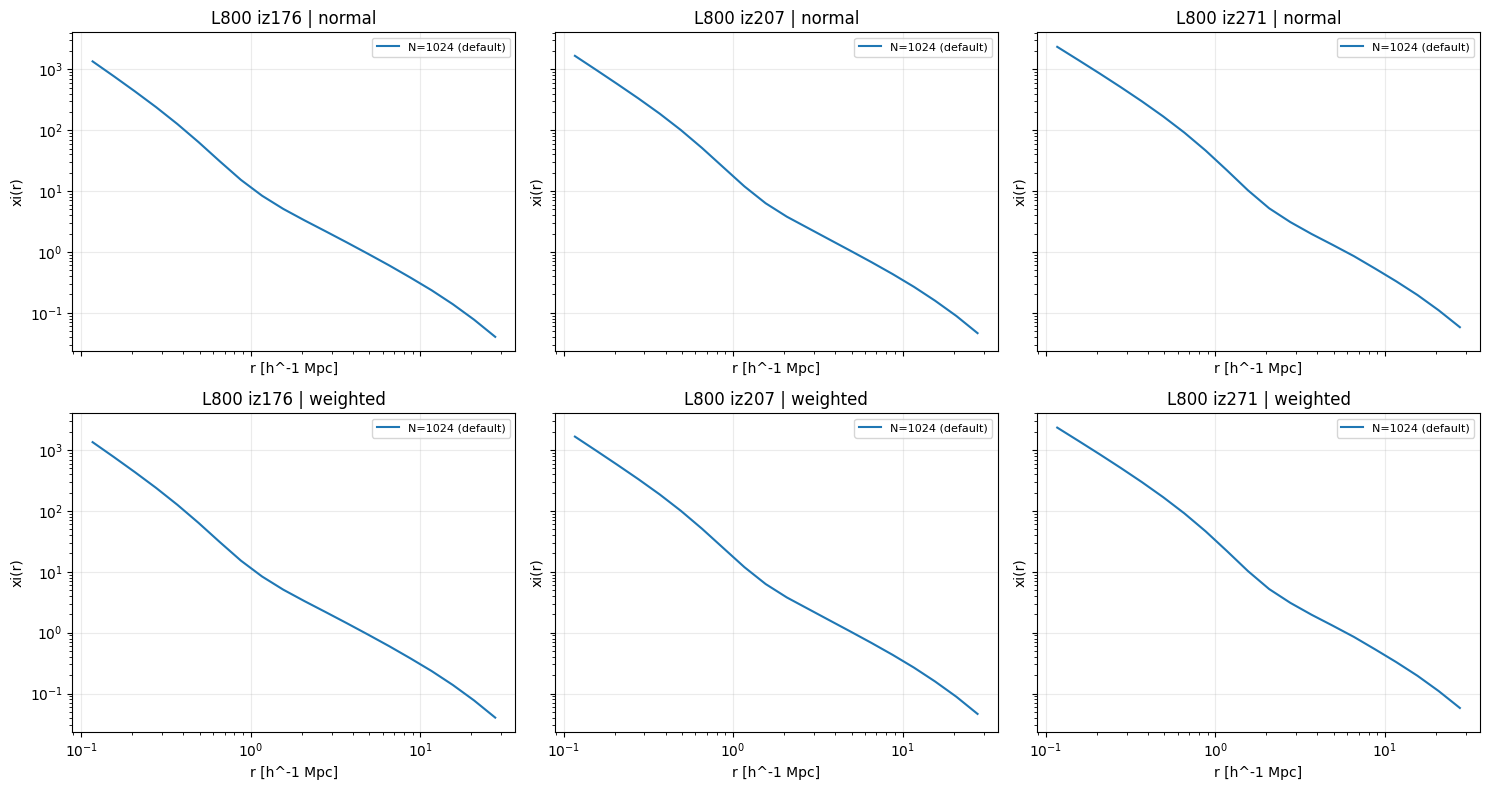

/tmp/ipykernel_87495/2506443024.py:128: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


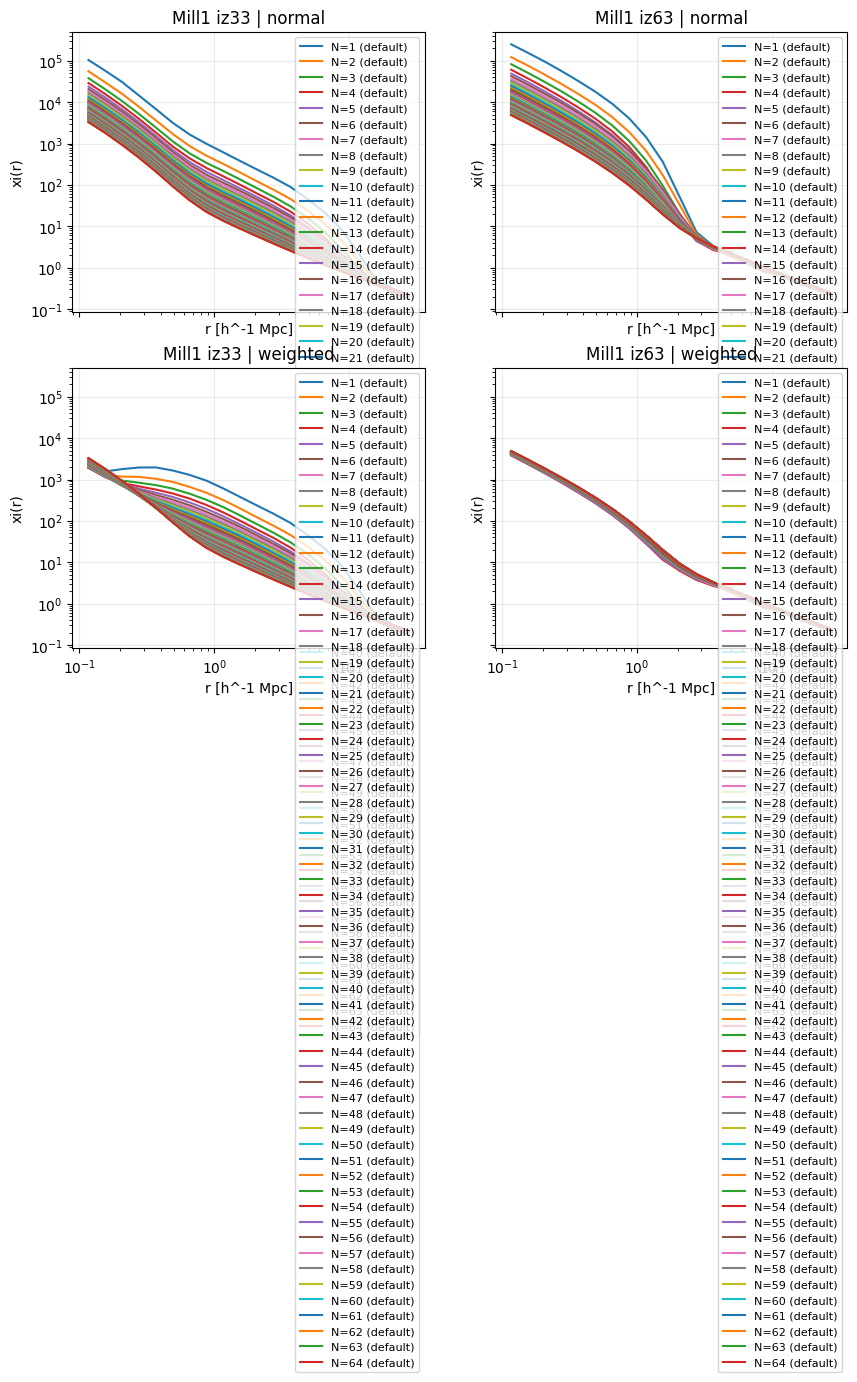

/tmp/ipykernel_87495/2506443024.py:128: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


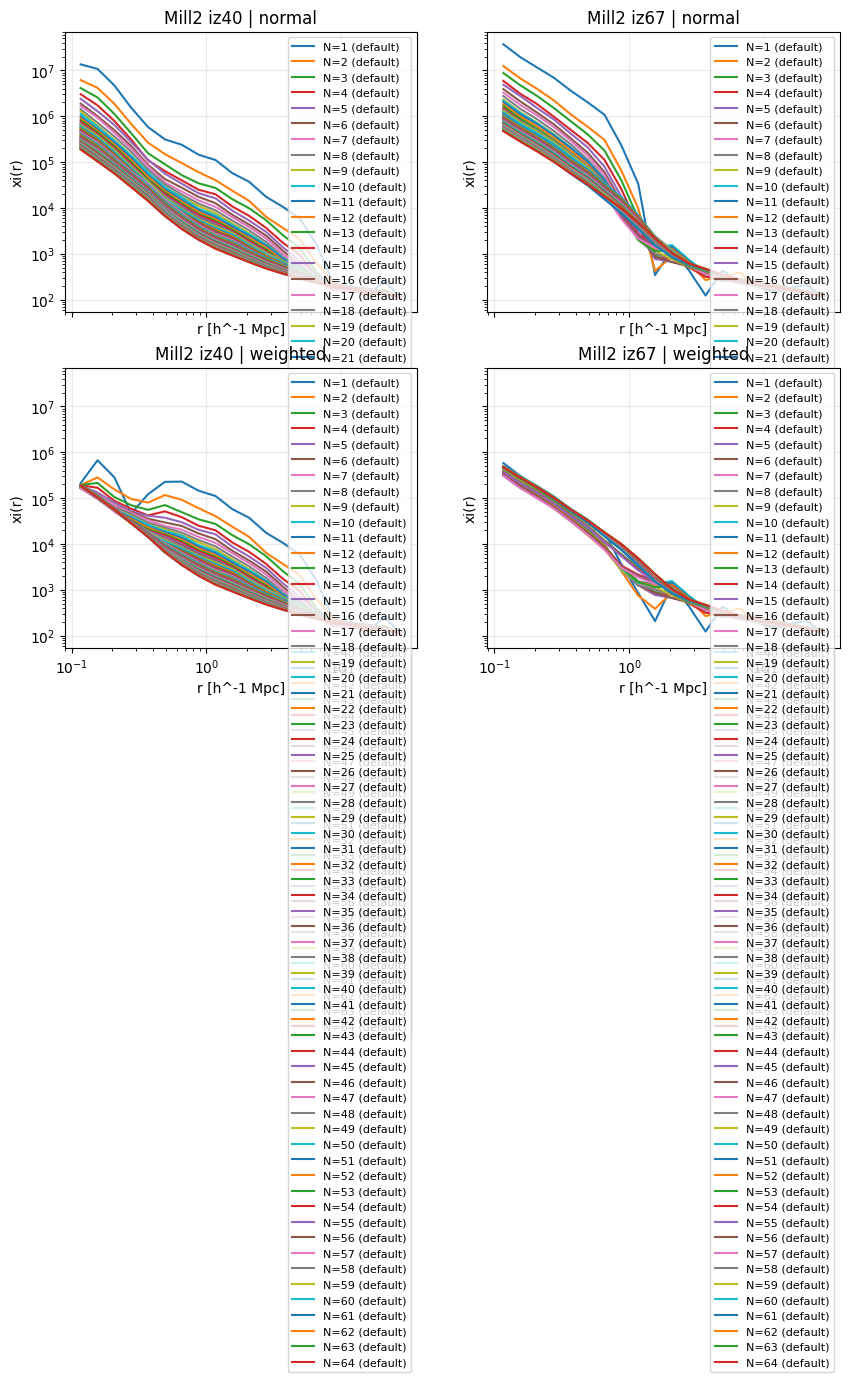

Built DataFrames: all_corr_df and summary_df


In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


MODEL_NAMES = {"gp14", "lc16"}


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    fallback = Path("/cosma/home/durham/dc-hick2/galform_analysis")
    return fallback if fallback.exists() else start


def infer_model(path: Path) -> str:
    for part in path.parts:
        if part in MODEL_NAMES:
            return part
    return "legacy"


def infer_batch_tag(path: Path) -> str:
    for part in path.parts:
        if part.startswith("n") and part[1:].isdigit():
            return part
        if part == "centrals_only" or part.startswith("mhalo"):
            return part
    return "default"


def infer_source_group(path: Path) -> str:
    parts = list(path.parts)
    if "convergence" in parts:
        idx = parts.index("convergence")
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return path.parent.name


repo_root = find_repo_root(Path.cwd().resolve())
print(f"cwd={Path.cwd()} | repo_root={repo_root}")

search_roots = [
    repo_root / "data" / "convergence" / "group_sampling_jobs",
    repo_root / "data" / "convergence" / "group_sampling_jobs_by_nvol",
    repo_root / "data" / "convergence" / "group_sampling_halo_filter_sets",
]

csv_paths = []
for root in search_roots:
    if root.exists():
        csv_paths.extend(sorted(root.rglob("group_sampling_convergence_*.csv")))

if not csv_paths:
    raise FileNotFoundError("No group_sampling_convergence CSV files found under data/convergence.")

print(f"Found {len(csv_paths)} CSV files")

re_mode = re.compile(r"group_sampling_convergence_(normal|weighted)_(.+)_iz(\d+)\.csv$")
re_nomode = re.compile(r"group_sampling_convergence_(.+)_iz(\d+)\.csv$")

frames = []
for p in csv_paths:
    name = p.name
    m_mode = re_mode.match(name)
    m_nomode = re_nomode.match(name)

    model = infer_model(p)
    batch_tag = infer_batch_tag(p)
    source_group = infer_source_group(p)

    df = pd.read_csv(p)

    if m_mode:
        mode, sim, iz = m_mode.groups()
        if "xi" not in df.columns:
            continue
        tidy = df.copy()
        tidy["model"] = model
        tidy["mode"] = mode
        tidy["sim"] = sim
        tidy["iz"] = int(iz)
        tidy["source_group"] = source_group
        tidy["batch_tag"] = batch_tag
        tidy["source_file"] = str(p)
        frames.append(
            tidy[["model", "sim", "iz", "mode", "n_subvol", "r", "xi", "ngal", "source_group", "batch_tag", "source_file"]]
        )
        continue

    if m_nomode and {"xi_standard", "xi_corrected"}.issubset(df.columns):
        sim, iz = m_nomode.groups()
        base_cols = ["n_subvol", "r", "ngal"]

        dfn = df[base_cols + ["xi_standard"]].rename(columns={"xi_standard": "xi"}).copy()
        dfn["model"] = model
        dfn["mode"] = "normal"
        dfn["sim"] = sim
        dfn["iz"] = int(iz)
        dfn["source_group"] = source_group
        dfn["batch_tag"] = batch_tag
        dfn["source_file"] = str(p)

        dfw = df[base_cols + ["xi_corrected"]].rename(columns={"xi_corrected": "xi"}).copy()
        dfw["model"] = model
        dfw["mode"] = "weighted"
        dfw["sim"] = sim
        dfw["iz"] = int(iz)
        dfw["source_group"] = source_group
        dfw["batch_tag"] = batch_tag
        dfw["source_file"] = str(p)

        frames.extend([
            dfn[["model", "sim", "iz", "mode", "n_subvol", "r", "xi", "ngal", "source_group", "batch_tag", "source_file"]],
            dfw[["model", "sim", "iz", "mode", "n_subvol", "r", "xi", "ngal", "source_group", "batch_tag", "source_file"]],
        ])

if not frames:
    raise RuntimeError("CSV files were found but none matched expected column/filename formats.")

all_corr_df = pd.concat(frames, ignore_index=True)
all_corr_df["model_priority"] = np.where(all_corr_df["model"] == "legacy", 1, 0)
all_corr_df = all_corr_df.sort_values([
    "sim", "iz", "mode", "source_group", "batch_tag", "n_subvol", "r", "model_priority", "model"
]).drop_duplicates(subset=["sim", "iz", "mode", "source_group", "batch_tag", "n_subvol", "r", "xi", "ngal"], keep="first").drop(columns="model_priority")
all_corr_df = all_corr_df.sort_values(["model", "sim", "iz", "mode", "source_group", "batch_tag", "n_subvol", "r"]).reset_index(drop=True)

summary_df = (
    all_corr_df.groupby(["model", "sim", "iz", "mode", "source_group", "n_subvol", "batch_tag"], as_index=False)
    .agg(n_rows=("r", "size"), n_gal=("ngal", "max"))
    .sort_values(["model", "sim", "iz", "mode", "source_group", "batch_tag", "n_subvol"])
)

display(summary_df)

for model in sorted(all_corr_df["model"].unique()):
    model_df = all_corr_df[all_corr_df["model"] == model]
    for sim in sorted(model_df["sim"].unique()):
        sim_df = model_df[model_df["sim"] == sim]
        iz_vals = sorted(sim_df["iz"].unique())

        if not iz_vals:
            continue

        fig, axes = plt.subplots(2, len(iz_vals), figsize=(5 * len(iz_vals), 8), squeeze=False, sharex=True, sharey=True)

        for col, iz in enumerate(iz_vals):
            for row, mode in enumerate(["normal", "weighted"]):
                ax = axes[row, col]
                sub = sim_df[(sim_df["iz"] == iz) & (sim_df["mode"] == mode)]
                if sub.empty:
                    ax.set_visible(False)
                    continue

                for (source_group, batch_tag, n_subvol), g in sub.groupby(["source_group", "batch_tag", "n_subvol"], sort=True):
                    g = g.sort_values("r")
                    valid = np.isfinite(g["xi"].values) & (g["xi"].values > 0)
                    if np.count_nonzero(valid) == 0:
                        continue
                    label = f"{source_group} | {batch_tag} | N={int(n_subvol)}"
                    ax.plot(g["r"].values[valid], g["xi"].values[valid], lw=1.5, label=label)

                ax.set_xscale("log")
                ax.set_yscale("log")
                ax.set_xlabel("r [h^-1 Mpc]")
                ax.set_ylabel("xi(r)")
                ax.set_title(f"{model} | {sim} iz{iz} | {mode}")
                ax.grid(alpha=0.25)
                ax.legend(fontsize=8, ncol=1)

        fig.tight_layout()
        plt.show()

print("Built DataFrames: all_corr_df and summary_df")

cwd=/cosma/home/durham/dc-hick2/galform_analysis/examples/subvolume_statistics | repo_root=/cosma/home/durham/dc-hick2/galform_analysis
Found 36 CSV files


,model,sim,iz,mode,source_group,n_subvol,batch_tag,n_bins,n_gal
0,legacy,L800,176,normal,group_sampling_jobs,800,default,20,3807976
1,legacy,L800,176,normal,group_sampling_jobs,1024,default,20,4835692
6,legacy,L800,176,normal,group_sampling_jobs_by_nvol,1024,n1024,20,4835692
2,legacy,L800,176,normal,group_sampling_jobs_by_nvol,600,n600,20,2864904
3,legacy,L800,176,normal,group_sampling_jobs_by_nvol,700,n700,20,3336002
4,legacy,L800,176,normal,group_sampling_jobs_by_nvol,800,n800,20,3807976
5,legacy,L800,176,normal,group_sampling_jobs_by_nvol,900,n900,20,4270066
7,legacy,L800,176,weighted,group_sampling_jobs,800,default,20,3807976
8,legacy,L800,176,weighted,group_sampling_jobs,1024,default,20,4835692
13,legacy,L800,176,weighted,group_sampling_jobs_by_nvol,1024,n1024,20,4835692


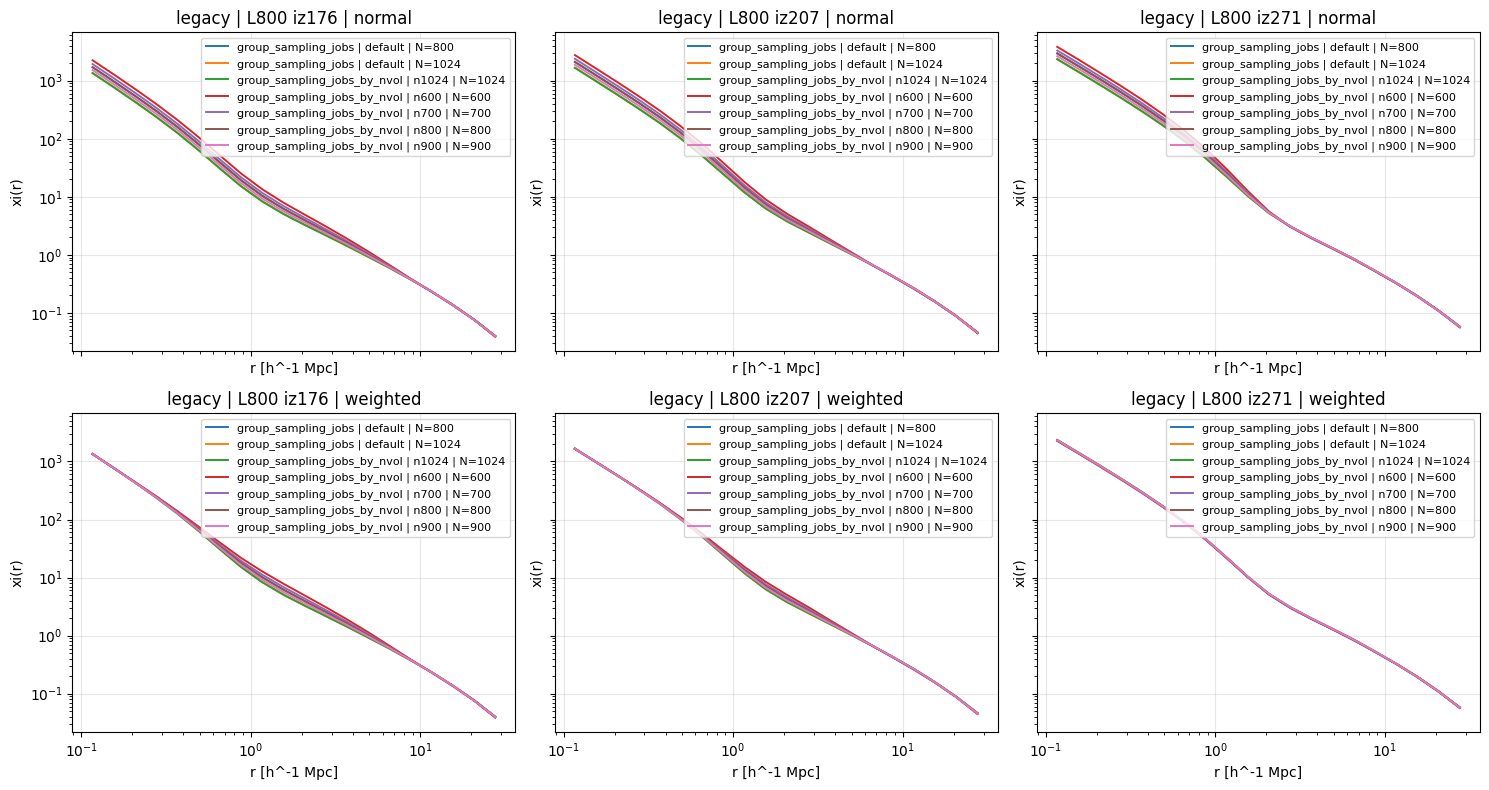

Built DataFrames: all_csv_corr_df and summary_df


In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


MODEL_NAMES = {"gp14", "lc16"}


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    fallback = Path("/cosma/home/durham/dc-hick2/galform_analysis")
    return fallback if fallback.exists() else start


def infer_model(path: Path) -> str:
    for part in path.parts:
        if part in MODEL_NAMES:
            return part
    return "legacy"


def infer_batch_tag(path: Path) -> str:
    for part in path.parts:
        if part.startswith("n") and part[1:].isdigit():
            return part
        if part == "centrals_only" or part.startswith("mhalo"):
            return part
    return "default"


def infer_source_group(path: Path) -> str:
    parts = list(path.parts)
    if "convergence" in parts:
        idx = parts.index("convergence")
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return path.parent.name


repo_root = find_repo_root(Path.cwd().resolve())
print(f"cwd={Path.cwd()} | repo_root={repo_root}")

search_roots = [
    repo_root / "data" / "convergence" / "group_sampling_jobs",
    repo_root / "data" / "convergence" / "group_sampling_jobs_by_nvol",
    repo_root / "data" / "convergence" / "group_sampling_halo_filter_sets",
]

csv_paths = []
for root in search_roots:
    if root.exists():
        csv_paths.extend(sorted(root.rglob("group_sampling_convergence_*.csv")))

if not csv_paths:
    raise FileNotFoundError(f"No convergence CSV files found under: {search_roots}")

print(f"Found {len(csv_paths)} CSV files")

re_mode = re.compile(r"group_sampling_convergence_(normal|weighted)_(.+)_iz(\d+)\.csv$")
re_nomode = re.compile(r"group_sampling_convergence_(.+)_iz(\d+)\.csv$")

rows = []
for p in csv_paths:
    m_mode = re_mode.match(p.name)
    m_nomode = re_nomode.match(p.name)
    df = pd.read_csv(p)

    model = infer_model(p)
    batch_tag = infer_batch_tag(p)
    source_group = infer_source_group(p)

    if m_mode and "xi" in df.columns:
        mode, sim, iz = m_mode.groups()
        t = df[["n_subvol", "r", "xi", "ngal"]].copy()
        t["model"] = model
        t["mode"] = mode
        t["sim"] = sim
        t["iz"] = int(iz)
        t["source_group"] = source_group
        t["batch_tag"] = batch_tag
        rows.append(t[["model", "sim", "iz", "mode", "n_subvol", "r", "xi", "ngal", "source_group", "batch_tag"]])
        continue

    if m_nomode and {"xi_standard", "xi_corrected"}.issubset(df.columns):
        sim, iz = m_nomode.groups()
        n = df[["n_subvol", "r", "ngal"]].copy()

        t1 = n.copy()
        t1["xi"] = df["xi_standard"].values
        t1["model"] = model
        t1["mode"] = "normal"
        t1["sim"] = sim
        t1["iz"] = int(iz)
        t1["source_group"] = source_group
        t1["batch_tag"] = batch_tag

        t2 = n.copy()
        t2["xi"] = df["xi_corrected"].values
        t2["model"] = model
        t2["mode"] = "weighted"
        t2["sim"] = sim
        t2["iz"] = int(iz)
        t2["source_group"] = source_group
        t2["batch_tag"] = batch_tag

        rows.extend([
            t1[["model", "sim", "iz", "mode", "n_subvol", "r", "xi", "ngal", "source_group", "batch_tag"]],
            t2[["model", "sim", "iz", "mode", "n_subvol", "r", "xi", "ngal", "source_group", "batch_tag"]],
        ])

if not rows:
    raise RuntimeError("CSV files found, but none matched expected schema")

all_csv_corr_df = pd.concat(rows, ignore_index=True)
all_csv_corr_df["model_priority"] = np.where(all_csv_corr_df["model"] == "legacy", 1, 0)
all_csv_corr_df = all_csv_corr_df.sort_values([
    "sim", "iz", "mode", "source_group", "batch_tag", "n_subvol", "r", "model_priority", "model"
]).drop_duplicates(subset=["sim", "iz", "mode", "source_group", "batch_tag", "n_subvol", "r", "xi", "ngal"], keep="first").drop(columns="model_priority")
all_csv_corr_df = all_csv_corr_df.sort_values(["model", "sim", "iz", "mode", "source_group", "batch_tag", "n_subvol", "r"]).reset_index(drop=True)

summary_df = (
    all_csv_corr_df.groupby(["model", "sim", "iz", "mode", "source_group", "n_subvol", "batch_tag"], as_index=False)
    .agg(n_bins=("r", "size"), n_gal=("ngal", "max"))
    .sort_values(["model", "sim", "iz", "mode", "source_group", "batch_tag", "n_subvol"])
)

display(summary_df)

for model in sorted(all_csv_corr_df["model"].unique()):
    model_df = all_csv_corr_df[all_csv_corr_df["model"] == model]
    for sim in sorted(model_df["sim"].unique()):
        sdf = model_df[model_df["sim"] == sim]
        iz_vals = sorted(sdf["iz"].unique())
        fig, axes = plt.subplots(2, len(iz_vals), figsize=(5 * len(iz_vals), 8), squeeze=False, sharex=True, sharey=True)

        for c, iz in enumerate(iz_vals):
            for r_i, mode in enumerate(["normal", "weighted"]):
                ax = axes[r_i, c]
                sub = sdf[(sdf["iz"] == iz) & (sdf["mode"] == mode)]
                if sub.empty:
                    ax.set_visible(False)
                    continue

                for (source_group, batch_tag, n_subvol), g in sub.groupby(["source_group", "batch_tag", "n_subvol"], sort=True):
                    g = g.sort_values("r")
                    v = np.isfinite(g["xi"].values) & (g["xi"].values > 0)
                    if np.count_nonzero(v) == 0:
                        continue
                    ax.plot(g["r"].values[v], g["xi"].values[v], lw=1.4, label=f"{source_group} | {batch_tag} | N={int(n_subvol)}")

                ax.set_xscale("log")
                ax.set_yscale("log")
                ax.set_xlabel("r [h^-1 Mpc]")
                ax.set_ylabel("xi(r)")
                ax.set_title(f"{model} | {sim} iz{iz} | {mode}")
                ax.grid(alpha=0.3)
                ax.legend(fontsize=8)

        fig.tight_layout()
        plt.show()

print("Built DataFrames: all_csv_corr_df and summary_df")